In [2]:
!pip install requests pandas numpy matplotlib scikit-learn

In [3]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

In [4]:
country = input("🌍 Enter country: ").strip()
city = input("🏙️ Enter city: ").strip()
prediction_date = input("📅 Enter prediction date (YYYY-MM-DD): ").strip()

# Validate date
try:
    date_obj = datetime.strptime(prediction_date, "%Y-%m-%d")
    print("\n✅ Date format is valid")
except ValueError:
    print("\n❌ Invalid date. Use YYYY-MM-DD")

🌍 Enter country:  jnd
🏙️ Enter city:  kpdj
📅 Enter prediction date (YYYY-MM-DD):  lknd



❌ Invalid date. Use YYYY-MM-DD


In [5]:
geocode_url = "https://geocoding-api.open-meteo.com/v1/search"

params = {
    "name": city,
    "count": 10,
    "language": "en",
    "format": "json"
}

response = requests.get(geocode_url, params=params)

if response.status_code == 200:
    data = response.json()

    if "results" in data:
        results = data["results"]

        # Try to find the requested country
        matches = [
            r for r in results
            if r.get("country", "").lower() == country.lower()
        ]

        if matches:
            location = matches[0]
        else:
            location = results[0]

        latitude = location["latitude"]
        longitude = location["longitude"]
        timezone = location.get("timezone", "Unknown")
        actual_city = location.get("name", city)
        actual_country = location.get("country", country)

        print("\n📍 LOCATION FOUND")
        print("-" * 40)
        print("City      :", actual_city)
        print("Country   :", actual_country)
        print("Latitude  :", latitude)
        print("Longitude :", longitude)
        print("Timezone  :", timezone)

    else:
        print("❌ City not found")

else:
    print("❌ Geocoding API error:", response.status_code)

❌ City not found


In [6]:
import requests
import pandas as pd

latitude = 52.52
longitude = 13.41

url = "https://api.open-meteo.com/v1/forecast"

params = {
    "latitude": latitude,
    "longitude": longitude,
    "current": "temperature_2m,wind_speed_10m",
    "hourly": "temperature_2m,relative_humidity_2m,wind_speed_10m"
}

response = requests.get(url, params=params)

data = response.json()

print(data)

{'latitude': 52.52, 'longitude': 13.419998, 'generationtime_ms': 0.3323554992675781, 'utc_offset_seconds': 0, 'timezone': 'GMT', 'timezone_abbreviation': 'GMT', 'elevation': 38.0, 'current_units': {'time': 'iso8601', 'interval': 'seconds', 'temperature_2m': '°C', 'wind_speed_10m': 'km/h'}, 'current': {'time': '2026-09-30T07:45', 'interval': 900, 'temperature_2m': 15.7, 'wind_speed_10m': 12.1}, 'hourly_units': {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'wind_speed_10m': 'km/h'}, 'hourly': {'time': ['2026-09-30T00:00', '2026-09-30T01:00', '2026-09-30T02:00', '2026-09-30T03:00', '2026-09-30T04:00', '2026-09-30T05:00', '2026-09-30T06:00', '2026-09-30T07:00', '2026-09-30T08:00', '2026-09-30T09:00', '2026-09-30T10:00', '2026-09-30T11:00', '2026-09-30T12:00', '2026-09-30T13:00', '2026-09-30T14:00', '2026-09-30T15:00', '2026-09-30T16:00', '2026-09-30T17:00', '2026-09-30T18:00', '2026-09-30T19:00', '2026-09-30T20:00', '2026-09-30T21:00', '2026-09-30T22:00', '2026-0

In [7]:
hourly = data["hourly"]

df = pd.DataFrame({
    "time": hourly["time"],
    "temperature": hourly["temperature_2m"],
    "humidity": hourly["relative_humidity_2m"],
    "wind_speed": hourly["wind_speed_10m"]
})

df.head()

,time,temperature,humidity,wind_speed
0,2026-09-30T00:00,15.7,62,10.3
1,2026-09-30T01:00,15.0,64,10.7
2,2026-09-30T02:00,14.4,68,11.0
3,2026-09-30T03:00,14.1,69,10.8
4,2026-09-30T04:00,13.7,70,10.3


In [8]:
latitude = 52.52
longitude = 13.41

In [9]:
import requests

country = input("🌍 Enter country: ").strip()
city = input("🏙️ Enter city: ").strip()

geocode_url = "https://geocoding-api.open-meteo.com/v1/search"

params = {
    "name": city,
    "count": 10,
    "language": "en",
    "format": "json"
}

response = requests.get(geocode_url, params=params)

if response.status_code != 200:
    print("❌ Geocoding API error:", response.status_code)

else:
    data = response.json()

    if "results" not in data:
        print("❌ City not found.")

    else:
        results = data["results"]

        # Find city matching the requested country
        matches = [
            r for r in results
            if r.get("country", "").lower() == country.lower()
        ]

        if len(matches) == 0:
            print("❌ City not found in that country.")
            print("\nAvailable results:")

            for r in results:
                print(
                    r.get("name"),
                    "-",
                    r.get("country"),
                    "-",
                    r.get("latitude"),
                    r.get("longitude")
                )

        else:
            location = matches[0]

            latitude = location["latitude"]
            longitude = location["longitude"]
            timezone = location.get("timezone", "Unknown")

            print("\n✅ LOCATION FOUND")
            print("=" * 40)
            print("City      :", location["name"])
            print("Country   :", location["country"])
            print("Latitude  :", latitude)
            print("Longitude :", longitude)
            print("Timezone  :", timezone)

🌍 Enter country:  aef
🏙️ Enter city:  asef


❌ City not found in that country.

Available results:
Āsefīān - Iran - 30.1 51.5
Āşefābād - Iran - 35.08422 47.74974
Āşefābād - Iran - 36.44069 61.14902
Asefachew - Ethiopia - 9.93092 39.85315
Åsefjell - Norway - 58.53319 6.58555
Åsefjell - Norway - 58.64152 7.97178
Åsefjellet - Norway - 61.85821 6.6395
Åsefjellene - Norway - 58.17307 7.15136
Åsefjellnyken - Norway - 61.95005 5.84414


In [10]:
prediction_date = input(
    "\n📅 Enter prediction date (YYYY-MM-DD): "
).strip()

from datetime import datetime

try:
    date_obj = datetime.strptime(
        prediction_date,
        "%Y-%m-%d"
    )

    print("✅ Valid date:", prediction_date)

except ValueError:
    print("❌ Invalid date.")
    print("Use format: YYYY-MM-DD")


📅 Enter prediction date (YYYY-MM-DD):  


❌ Invalid date.
Use format: YYYY-MM-DD


In [11]:
from datetime import datetime
import requests

# Convert user's date into proper YYYY-MM-DD format
date_obj = datetime.strptime(prediction_date, "%Y-%m-%d")
prediction_date = date_obj.strftime("%Y-%m-%d")

print("Selected date:", prediction_date)

# Historical API
weather_url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": prediction_date,
    "end_date": prediction_date,
    "hourly": "temperature_2m,relative_humidity_2m,wind_speed_10m,cloud_cover,surface_pressure",
    "timezone": "auto"
}

response = requests.get(weather_url, params=params)

print("Status Code:", response.status_code)

if response.status_code == 200:
    weather_data = response.json()
    print("✅ Historical weather data received!")

else:
    print("❌ Weather API error")
    print(response.text)

ValueError: time data '' does not match format '%Y-%m-%d'

In [12]:
weather_data["hourly"].keys()

NameError: name 'weather_data' is not defined

In [13]:
weather_url = "https://api.open-meteo.com/v1/forecast"

params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": prediction_date,
    "end_date": prediction_date,
    "hourly": "temperature_2m,relative_humidity_2m,precipitation_probability,wind_speed_10m,cloud_cover,surface_pressure",
    "timezone": "auto"
}

response = requests.get(weather_url, params=params)

print("Status Code:", response.status_code)

if response.status_code == 200:
    weather_data = response.json()
    print("✅ Weather data received!")

else:
    print("❌ Weather API error")
    print("Message:", response.text)

Status Code: 200
✅ Weather data received!


In [14]:
weather_data["hourly"].keys()

dict_keys(['time', 'temperature_2m', 'relative_humidity_2m', 'precipitation_probability', 'wind_speed_10m', 'cloud_cover', 'surface_pressure'])

In [15]:
hourly = weather_data["hourly"]

weather_df = pd.DataFrame({
    "time": hourly["time"],
    "temperature": hourly["temperature_2m"],
    "humidity": hourly["relative_humidity_2m"],
    "wind_speed": hourly["wind_speed_10m"],
    "cloud_cover": hourly["cloud_cover"],
    "pressure": hourly["surface_pressure"]
})

weather_df.head()

,time,temperature,humidity,wind_speed,cloud_cover,pressure
0,2026-09-30T00:00,17.0,59,10.0,100,1020.5
1,2026-09-30T01:00,16.2,62,10.8,100,1020.4
2,2026-09-30T02:00,15.7,62,10.3,100,1020.2
3,2026-09-30T03:00,15.0,64,10.7,85,1020.6
4,2026-09-30T04:00,14.4,68,11.0,100,1020.6


In [16]:
import pandas as pd

hourly = weather_data["hourly"]

weather_df = pd.DataFrame({
    "time": hourly["time"],
    "temperature": hourly["temperature_2m"],
    "humidity": hourly["relative_humidity_2m"],
    "wind_speed": hourly["wind_speed_10m"],
    "cloud_cover": hourly["cloud_cover"],
    "pressure": hourly["surface_pressure"]
})

weather_df.head(10)

,time,temperature,humidity,wind_speed,cloud_cover,pressure
0,2026-09-30T00:00,17.0,59,10.0,100,1020.5
1,2026-09-30T01:00,16.2,62,10.8,100,1020.4
2,2026-09-30T02:00,15.7,62,10.3,100,1020.2
3,2026-09-30T03:00,15.0,64,10.7,85,1020.6
4,2026-09-30T04:00,14.4,68,11.0,100,1020.6
5,2026-09-30T05:00,14.1,69,10.8,24,1019.6
6,2026-09-30T06:00,13.7,70,10.3,100,1019.9
7,2026-09-30T07:00,13.5,70,11.0,100,1020.4
8,2026-09-30T08:00,13.1,68,11.3,100,1020.7
9,2026-09-30T09:00,14.5,64,11.3,95,1021.0


In [17]:
print("Rows:", len(weather_df))
print("Columns:", weather_df.columns.tolist())

print("\nMissing values:")
print(weather_df.isnull().sum())

Rows: 168
Columns: ['time', 'temperature', 'humidity', 'wind_speed', 'cloud_cover', 'pressure']

Missing values:
time           0
temperature    0
humidity       0
wind_speed     0
cloud_cover    0
pressure       0
dtype: int64


In [18]:
daily_summary = pd.DataFrame({
    "date": [prediction_date],
    "avg_temperature": [weather_df["temperature"].mean()],
    "min_temperature": [weather_df["temperature"].min()],
    "max_temperature": [weather_df["temperature"].max()],
    "avg_humidity": [weather_df["humidity"].mean()],
    "avg_wind_speed": [weather_df["wind_speed"].mean()],
    "avg_cloud_cover": [weather_df["cloud_cover"].mean()],
    "avg_pressure": [weather_df["pressure"].mean()]
})

daily_summary

,date,avg_temperature,min_temperature,max_temperature,avg_humidity,avg_wind_speed,avg_cloud_cover,avg_pressure
0,,16.314881,11.1,24.5,68.464286,7.536905,88.97619,1019.7


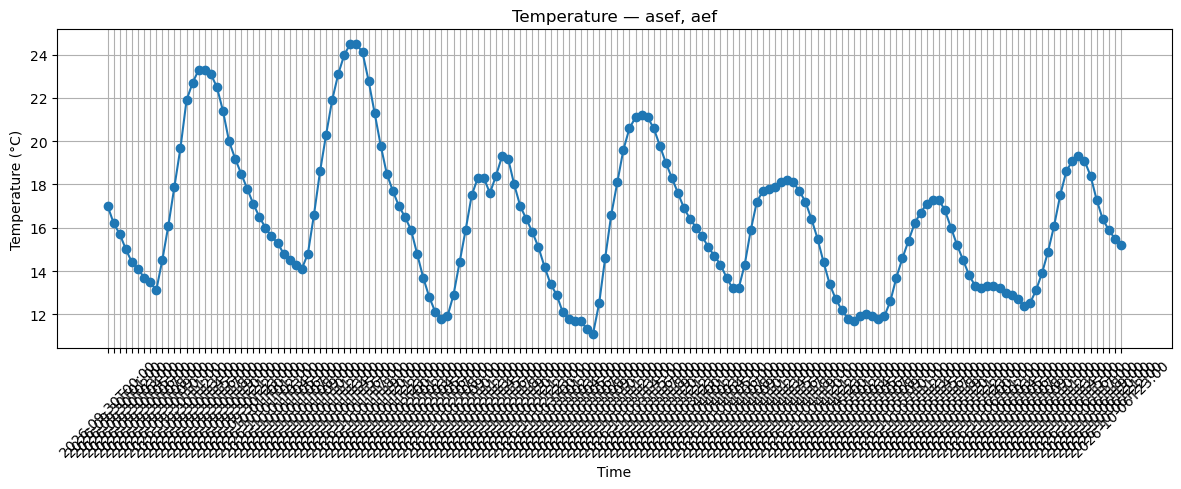

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    weather_df["time"],
    weather_df["temperature"],
    marker="o"
)

plt.title(f"Temperature — {city}, {country}")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [20]:
cities = [
    # Asia
    {"city": "Tokyo", "country": "Japan", "lat": 35.6762, "lon": 139.6503},
    {"city": "Mumbai", "country": "India", "lat": 19.0760, "lon": 72.8777},
    {"city": "Delhi", "country": "India", "lat": 28.6139, "lon": 77.2090},
    {"city": "Singapore", "country": "Singapore", "lat": 1.3521, "lon": 103.8198},
    {"city": "Seoul", "country": "South Korea", "lat": 37.5665, "lon": 126.9780},
    
    # Europe
    {"city": "London", "country": "United Kingdom", "lat": 51.5074, "lon": -0.1278},
    {"city": "Paris", "country": "France", "lat": 48.8566, "lon": 2.3522},
    {"city": "Berlin", "country": "Germany", "lat": 52.5200, "lon": 13.4050},
    {"city": "Rome", "country": "Italy", "lat": 41.9028, "lon": 12.4964},
    
    # North America
    {"city": "New York", "country": "USA", "lat": 40.7128, "lon": -74.0060},
    {"city": "Los Angeles", "country": "USA", "lat": 34.0522, "lon": -118.2437},
    {"city": "Toronto", "country": "Canada", "lat": 43.6532, "lon": -79.3832},
    
    # South America
    {"city": "São Paulo", "country": "Brazil", "lat": -23.5505, "lon": -46.6333},
    {"city": "Buenos Aires", "country": "Argentina", "lat": -34.6037, "lon": -58.3816},
    
    # Africa
    {"city": "Cairo", "country": "Egypt", "lat": 30.0444, "lon": 31.2357},
    {"city": "Nairobi", "country": "Kenya", "lat": -1.2921, "lon": 36.8219},
    
    # Oceania
    {"city": "Sydney", "country": "Australia", "lat": -33.8688, "lon": 151.2093},
    {"city": "Melbourne", "country": "Australia", "lat": -37.8136, "lon": 144.9631},
]

In [21]:
import requests
import pandas as pd
import time

START_DATE = "2020-01-01"
END_DATE = "2024-12-31"

all_data = []

for location in cities:

    print(
        f"Downloading: {location['city']}, "
        f"{location['country']}"
    )

    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": location["lat"],
        "longitude": location["lon"],
        "start_date": START_DATE,
        "end_date": END_DATE,
        "daily": [
            "temperature_2m_mean",
            "temperature_2m_max",
            "temperature_2m_min",
            "precipitation_sum",
            "rain_sum",
            "snowfall_sum",
            "wind_speed_10m_max",
            "wind_gusts_10m_max"
        ],
        "timezone": "auto"
    }

    response = requests.get(url, params=params)

    if response.status_code != 200:
        print("❌ Error:", response.text)
        continue

    data = response.json()

    daily = data["daily"]

    df = pd.DataFrame(daily)

    df["city"] = location["city"]
    df["country"] = location["country"]
    df["latitude"] = location["lat"]
    df["longitude"] = location["lon"]

    all_data.append(df)

    time.sleep(1)

print("\n✅ Download complete!")

Downloading: Tokyo, Japan
Downloading: Mumbai, India
Downloading: Delhi, India
Downloading: Singapore, Singapore
Downloading: Seoul, South Korea
Downloading: London, United Kingdom
Downloading: Paris, France
❌ Error: {"error":true,"reason":"Minutely API request limit exceeded. Please try again in one minute."}
Downloading: Berlin, Germany
❌ Error: {"reason":"Minutely API request limit exceeded. Please try again in one minute.","error":true}
Downloading: Rome, Italy
❌ Error: {"error":true,"reason":"Minutely API request limit exceeded. Please try again in one minute."}
Downloading: New York, USA
❌ Error: {"reason":"Minutely API request limit exceeded. Please try again in one minute.","error":true}
Downloading: Los Angeles, USA
❌ Error: {"reason":"Minutely API request limit exceeded. Please try again in one minute.","error":true}
Downloading: Toronto, Canada
❌ Error: {"reason":"Minutely API request limit exceeded. Please try again in one minute.","error":true}
Downloading: São Paulo, Braz

In [22]:
print("Successfully downloaded:", len(all_data))

for df in all_data:
    print(df["city"].iloc[0], len(df))

Successfully downloaded: 6
Tokyo 1827
Mumbai 1827
Delhi 1827
Singapore 1827
Seoul 1827
London 1827


In [ ]:
import requests
import pandas as pd
import time

START_DATE = "2020-01-01"
END_DATE = "2024-12-31"

# Cities that failed previously
failed_cities = [
    {"city": "São Paulo", "country": "Brazil", "lat": -23.5505, "lon": -46.6333},
    {"city": "Buenos Aires", "country": "Argentina", "lat": -34.6037, "lon": -58.3816},
    {"city": "Cairo", "country": "Egypt", "lat": 30.0444, "lon": 31.2357},
    {"city": "Nairobi", "country": "Kenya", "lat": -1.2921, "lon": 36.8219},
    {"city": "Sydney", "country": "Australia", "lat": -33.8688, "lon": 151.2093},
    {"city": "Melbourne", "country": "Australia", "lat": -37.8136, "lon": 144.9631}
]

for location in failed_cities:

    print(f"\nDownloading: {location['city']}, {location['country']}")

    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": location["lat"],
        "longitude": location["lon"],
        "start_date": START_DATE,
        "end_date": END_DATE,
        "daily": "temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,rain_sum,snowfall_sum,wind_speed_10m_max,wind_gusts_10m_max",
        "timezone": "auto"
    }

    while True:

        response = requests.get(url, params=params)

        if response.status_code == 200:

            data = response.json()
            daily = data["daily"]

            df = pd.DataFrame(daily)

            df["city"] = location["city"]
            df["country"] = location["country"]
            df["latitude"] = location["lat"]
            df["longitude"] = location["lon"]

            all_data.append(df)

            print("✅ Downloaded:", len(df), "days")
            break

        elif response.status_code == 429:

            print("⏳ API limit reached. Waiting 65 seconds...")
            time.sleep(65)

        else:

            print("❌ Error:", response.text)
            break

    # Wait between successful requests
    time.sleep(5)

print("\n✅ Finished downloading failed cities.")

In [24]:
weather_dataset = pd.concat(
    all_data,
    ignore_index=True
)

print("Dataset shape:", weather_dataset.shape)

Dataset shape: (21924, 13)


In [25]:
weather_dataset["city"].value_counts()

city
Tokyo           1827
Mumbai          1827
Delhi           1827
Singapore       1827
Seoul           1827
London          1827
São Paulo       1827
Buenos Aires    1827
Cairo           1827
Nairobi         1827
Sydney          1827
Melbourne       1827
Name: count, dtype: int64

In [26]:
weather_dataset.to_csv(
    "worldwide_weather_dataset.csv",
    index=False
)

print("✅ Worldwide dataset saved")

✅ Worldwide dataset saved


In [27]:
weather_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21924 entries, 0 to 21923
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   time                 21924 non-null  object 
 1   temperature_2m_mean  21924 non-null  float64
 2   temperature_2m_max   21924 non-null  float64
 3   temperature_2m_min   21924 non-null  float64
 4   precipitation_sum    21924 non-null  float64
 5   rain_sum             21924 non-null  float64
 6   snowfall_sum         21924 non-null  float64
 7   wind_speed_10m_max   21924 non-null  float64
 8   wind_gusts_10m_max   21924 non-null  float64
 9   city                 21924 non-null  object 
 10  country              21924 non-null  object 
 11  latitude             21924 non-null  float64
 12  longitude            21924 non-null  float64
dtypes: float64(10), object(3)
memory usage: 2.2+ MB


In [28]:
weather_dataset.isnull().sum()

time                   0
temperature_2m_mean    0
temperature_2m_max     0
temperature_2m_min     0
precipitation_sum      0
rain_sum               0
snowfall_sum           0
wind_speed_10m_max     0
wind_gusts_10m_max     0
city                   0
country                0
latitude               0
longitude              0
dtype: int64

In [29]:
weather_dataset.isnull().sum()

time                   0
temperature_2m_mean    0
temperature_2m_max     0
temperature_2m_min     0
precipitation_sum      0
rain_sum               0
snowfall_sum           0
wind_speed_10m_max     0
wind_gusts_10m_max     0
city                   0
country                0
latitude               0
longitude              0
dtype: int64

In [30]:
weather_dataset["date"] = pd.to_datetime(
    weather_dataset["date"]
)

KeyError: 'date'

In [31]:
print(weather_dataset.columns.tolist())

['time', 'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min', 'precipitation_sum', 'rain_sum', 'snowfall_sum', 'wind_speed_10m_max', 'wind_gusts_10m_max', 'city', 'country', 'latitude', 'longitude']


In [32]:
weather_dataset = weather_dataset.rename(
    columns={"time": "date"}
)

weather_dataset["date"] = pd.to_datetime(
    weather_dataset["date"]
)

print(weather_dataset.columns.tolist())

['date', 'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min', 'precipitation_sum', 'rain_sum', 'snowfall_sum', 'wind_speed_10m_max', 'wind_gusts_10m_max', 'city', 'country', 'latitude', 'longitude']


In [33]:
weather_dataset["year"] = weather_dataset["date"].dt.year
weather_dataset["month"] = weather_dataset["date"].dt.month
weather_dataset["day"] = weather_dataset["date"].dt.day
weather_dataset["day_of_year"] = weather_dataset["date"].dt.dayofyear

In [34]:
import numpy as np

weather_dataset["month_sin"] = np.sin(
    2 * np.pi * weather_dataset["month"] / 12
)

weather_dataset["month_cos"] = np.cos(
    2 * np.pi * weather_dataset["month"] / 12
)

weather_dataset["day_sin"] = np.sin(
    2 * np.pi * weather_dataset["day_of_year"] / 365
)

weather_dataset["day_cos"] = np.cos(
    2 * np.pi * weather_dataset["day_of_year"] / 365
)

In [35]:
import numpy as np

weather_dataset["month_sin"] = np.sin(
    2 * np.pi * weather_dataset["month"] / 12
)

weather_dataset["month_cos"] = np.cos(
    2 * np.pi * weather_dataset["month"] / 12
)

weather_dataset["day_sin"] = np.sin(
    2 * np.pi * weather_dataset["day_of_year"] / 365
)

weather_dataset["day_cos"] = np.cos(
    2 * np.pi * weather_dataset["day_of_year"] / 365
)

In [36]:
weather_dataset = weather_dataset.dropna(
    subset=["target_temperature"]
)

print(weather_dataset.shape)

KeyError: ['target_temperature']

In [37]:
print(weather_dataset.columns.tolist())

['date', 'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min', 'precipitation_sum', 'rain_sum', 'snowfall_sum', 'wind_speed_10m_max', 'wind_gusts_10m_max', 'city', 'country', 'latitude', 'longitude', 'year', 'month', 'day', 'day_of_year', 'month_sin', 'month_cos', 'day_sin', 'day_cos']


In [38]:
weather_dataset = weather_dataset.sort_values(
    ["city", "date"]
).reset_index(drop=True)

In [39]:
weather_dataset["target_temperature"] = (
    weather_dataset
    .groupby("city")["temperature_2m_mean"]
    .shift(-1)
)

print("Target column created!")
print(weather_dataset[[
    "city",
    "date",
    "temperature_2m_mean",
    "target_temperature"
]].head(10))

Target column created!
           city       date  temperature_2m_mean  target_temperature
0  Buenos Aires 2020-01-01                 21.8                21.4
1  Buenos Aires 2020-01-02                 21.4                22.5
2  Buenos Aires 2020-01-03                 22.5                23.3
3  Buenos Aires 2020-01-04                 23.3                24.3
4  Buenos Aires 2020-01-05                 24.3                21.9
5  Buenos Aires 2020-01-06                 21.9                22.1
6  Buenos Aires 2020-01-07                 22.1                25.1
7  Buenos Aires 2020-01-08                 25.1                25.2
8  Buenos Aires 2020-01-09                 25.2                25.2
9  Buenos Aires 2020-01-10                 25.2                24.6


In [40]:
weather_dataset = weather_dataset.dropna(
    subset=["target_temperature"]
).reset_index(drop=True)

print("Dataset shape:", weather_dataset.shape)

Dataset shape: (21912, 22)


In [41]:
print(weather_dataset[[
    "city",
    "date",
    "temperature_2m_mean",
    "target_temperature"
]].tail(10))

        city       date  temperature_2m_mean  target_temperature
21902  Tokyo 2024-12-21                  7.7                 6.8
21903  Tokyo 2024-12-22                  6.8                 5.3
21904  Tokyo 2024-12-23                  5.3                 5.2
21905  Tokyo 2024-12-24                  5.2                 6.3
21906  Tokyo 2024-12-25                  6.3                 7.7
21907  Tokyo 2024-12-26                  7.7                 6.5
21908  Tokyo 2024-12-27                  6.5                 4.6
21909  Tokyo 2024-12-28                  4.6                 5.1
21910  Tokyo 2024-12-29                  5.1                 5.7
21911  Tokyo 2024-12-30                  5.7                 6.7


In [42]:
print(weather_dataset.columns.tolist())

['date', 'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min', 'precipitation_sum', 'rain_sum', 'snowfall_sum', 'wind_speed_10m_max', 'wind_gusts_10m_max', 'city', 'country', 'latitude', 'longitude', 'year', 'month', 'day', 'day_of_year', 'month_sin', 'month_cos', 'day_sin', 'day_cos', 'target_temperature']


In [43]:
features = [
    "latitude",
    "longitude",
    "month",
    "day_of_year",
    "month_sin",
    "month_cos",
    "day_sin",
    "day_cos",
    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",
    "precipitation_sum",
    "rain_sum",
    "snowfall_sum",
    "wind_speed_10m_max",
    "wind_gusts_10m_max"
]

X = weather_dataset[features]
y = weather_dataset["target_temperature"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (21912, 16)
y shape: (21912,)


In [44]:
train_data = weather_dataset[
    weather_dataset["year"] <= 2023
]

test_data = weather_dataset[
    weather_dataset["year"] == 2024
]

X_train = train_data[features]
y_train = train_data["target_temperature"]

X_test = test_data[features]
y_test = test_data["target_temperature"]

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 17532
Testing samples : 4380


In [45]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

print("Training model...")

model.fit(X_train, y_train)

print("✅ Model trained!")

Training model...
✅ Model trained!


In [46]:
y_pred = model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[24.8586158  23.3652963  24.6497869  23.80810343 25.8064232  25.15412903
 23.4289316  24.00350442 27.09440377 25.17371451]


In [47]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("📊 MODEL PERFORMANCE")
print("=" * 40)
print(f"MAE  : {mae:.2f} °C")
print(f"RMSE : {rmse:.2f} °C")
print(f"R²   : {r2:.3f}")

📊 MODEL PERFORMANCE
MAE  : 1.10 °C
RMSE : 1.56 °C
R²   : 0.959


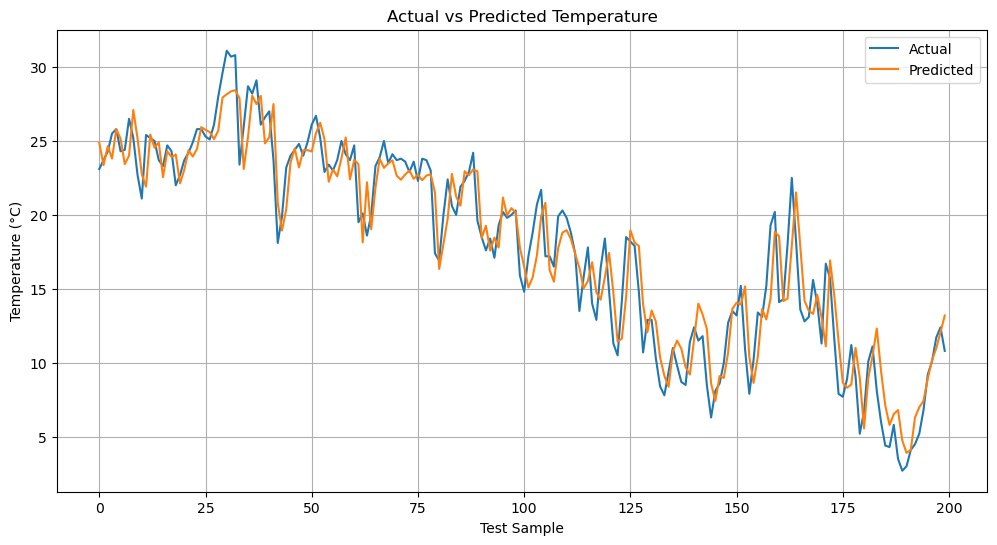

In [48]:
plt.figure(figsize=(12, 6))

plt.plot(
    y_test.values[:200],
    label="Actual"
)

plt.plot(
    y_pred[:200],
    label="Predicted"
)

plt.title("Actual vs Predicted Temperature")
plt.xlabel("Test Sample")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)

plt.show()

In [49]:
def predict_temperature(city_name, country_name, prediction_date):
    
    # Find the location in our training dataset
    location = weather_dataset[
        (weather_dataset["city"].str.lower() == city_name.lower()) &
        (weather_dataset["country"].str.lower() == country_name.lower())
    ]
    
    if location.empty:
        print("❌ City is not available in the current model dataset.")
        return None
    
    # Convert date
    prediction_date = pd.to_datetime(prediction_date)
    
    # Extract date features
    month = prediction_date.month
    day_of_year = prediction_date.dayofyear
    
    month_sin = np.sin(2 * np.pi * month / 12)
    month_cos = np.cos(2 * np.pi * month / 12)
    
    day_sin = np.sin(2 * np.pi * day_of_year / 365)
    day_cos = np.cos(2 * np.pi * day_of_year / 365)
    
    # Use recent weather for this location
    city_data = location.sort_values("date")
    
    latest = city_data.iloc[-1]
    
    input_data = pd.DataFrame([{
        "latitude": latest["latitude"],
        "longitude": latest["longitude"],
        "month": month,
        "day_of_year": day_of_year,
        "month_sin": month_sin,
        "month_cos": month_cos,
        "day_sin": day_sin,
        "day_cos": day_cos,
        "temperature_2m_mean": latest["temperature_2m_mean"],
        "temperature_2m_max": latest["temperature_2m_max"],
        "temperature_2m_min": latest["temperature_2m_min"],
        "precipitation_sum": latest["precipitation_sum"],
        "rain_sum": latest["rain_sum"],
        "snowfall_sum": latest["snowfall_sum"],
        "wind_speed_10m_max": latest["wind_speed_10m_max"],
        "wind_gusts_10m_max": latest["wind_gusts_10m_max"]
    }])
    
    prediction = model.predict(input_data[features])[0]
    
    print("\n🌍 WEATHER PREDICTION")
    print("=" * 40)
    print("City     :", city_name)
    print("Country  :", country_name)
    print("Date     :", prediction_date.strftime("%Y-%m-%d"))
    print(f"Temperature: {prediction:.2f} °C")
    
    return prediction

In [50]:
predict_temperature(
    "Tokyo",
    "Japan",
    "2024-10-15"
)


🌍 WEATHER PREDICTION
City     : Tokyo
Country  : Japan
Date     : 2024-10-15
Temperature: 6.78 °C


np.float64(6.783076190476189)

In [51]:
# Make sure data is sorted correctly
weather_dataset = weather_dataset.sort_values(
    ["city", "date"]
).reset_index(drop=True)

# Previous temperatures
weather_dataset["temp_lag_1"] = (
    weather_dataset.groupby("city")["temperature_2m_mean"].shift(1)
)

weather_dataset["temp_lag_2"] = (
    weather_dataset.groupby("city")["temperature_2m_mean"].shift(2)
)

weather_dataset["temp_lag_3"] = (
    weather_dataset.groupby("city")["temperature_2m_mean"].shift(3)
)

# Previous day's weather
weather_dataset["humidity_lag_1"] = (
    weather_dataset.groupby("city")["humidity"].shift(1)
    if "humidity" in weather_dataset.columns
    else np.nan
)

# 7-day rolling temperature average
weather_dataset["temp_rolling_7"] = (
    weather_dataset
    .groupby("city")["temperature_2m_mean"]
    .transform(
        lambda x: x.shift(1).rolling(7).mean()
    )
)

print(weather_dataset[
    [
        "city",
        "date",
        "temperature_2m_mean",
        "temp_lag_1",
        "temp_lag_2",
        "temp_lag_3",
        "temp_rolling_7"
    ]
].head(15))

            city       date  temperature_2m_mean  temp_lag_1  temp_lag_2  \
0   Buenos Aires 2020-01-01                 21.8         NaN         NaN   
1   Buenos Aires 2020-01-02                 21.4        21.8         NaN   
2   Buenos Aires 2020-01-03                 22.5        21.4        21.8   
3   Buenos Aires 2020-01-04                 23.3        22.5        21.4   
4   Buenos Aires 2020-01-05                 24.3        23.3        22.5   
5   Buenos Aires 2020-01-06                 21.9        24.3        23.3   
6   Buenos Aires 2020-01-07                 22.1        21.9        24.3   
7   Buenos Aires 2020-01-08                 25.1        22.1        21.9   
8   Buenos Aires 2020-01-09                 25.2        25.1        22.1   
9   Buenos Aires 2020-01-10                 25.2        25.2        25.1   
10  Buenos Aires 2020-01-11                 24.6        25.2        25.2   
11  Buenos Aires 2020-01-12                 24.2        24.6        25.2   
12  Buenos A

In [52]:
weather_dataset = weather_dataset.dropna(
    subset=[
        "temp_lag_1",
        "temp_lag_2",
        "temp_lag_3",
        "temp_rolling_7",
        "target_temperature"
    ]
).reset_index(drop=True)

print("Dataset:", weather_dataset.shape)

Dataset: (21828, 27)


In [53]:

features_v2 = [
    "latitude",
    "longitude",

    # Date
    "month",
    "day_of_year",
    "month_sin",
    "month_cos",
    "day_sin",
    "day_cos",

    # Current weather
    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",
    "precipitation_sum",
    "rain_sum",
    "snowfall_sum",
    "wind_speed_10m_max",
    "wind_gusts_10m_max",

    # Historical weather
    "temp_lag_1",
    "temp_lag_2",
    "temp_lag_3",
    "temp_rolling_7"
]

X = weather_dataset[features_v2]
y = weather_dataset["target_temperature"]

print("Features:", len(features_v2))
print("Samples:", len(X))

Features: 20
Samples: 21828


In [54]:
train_data = weather_dataset[
    weather_dataset["year"] <= 2023
]

test_data = weather_dataset[
    weather_dataset["year"] == 2024
]

X_train = train_data[features_v2]
y_train = train_data["target_temperature"]

X_test = test_data[features_v2]
y_test = test_data["target_temperature"]

print("Training:", len(X_train))
print("Testing :", len(X_test))

Training: 17448
Testing : 4380


In [55]:
from sklearn.ensemble import RandomForestRegressor

model_v2 = RandomForestRegressor(
    n_estimators=300,
    max_depth=25,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

print("Training improved model...")

model_v2.fit(X_train, y_train)

print("✅ Improved model trained!")

Training improved model...
✅ Improved model trained!


In [56]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_v2 = model_v2.predict(X_test)

mae_v2 = mean_absolute_error(y_test, y_pred_v2)

rmse_v2 = np.sqrt(
    mean_squared_error(y_test, y_pred_v2)
)

r2_v2 = r2_score(y_test, y_pred_v2)

print("📊 IMPROVED MODEL")
print("=" * 40)
print(f"MAE  : {mae_v2:.2f} °C")
print(f"RMSE : {rmse_v2:.2f} °C")
print(f"R²   : {r2_v2:.3f}")

📊 IMPROVED MODEL
MAE  : 1.08 °C
RMSE : 1.53 °C
R²   : 0.961


In [57]:
country_input = input("🌍 Country: ").strip()
city_input = input("🏙️ City: ").strip()
date_input = input("📅 Prediction date (YYYY-MM-DD): ").strip()

date_input = pd.to_datetime(date_input).strftime("%Y-%m-%d")

print("\nRequest:")
print("Country:", country_input)
print("City:", city_input)
print("Date:", date_input)

🌍 Country:  India
🏙️ City:  Mumbhai
📅 Prediction date (YYYY-MM-DD):  2025-9-4



Request:
Country: India
City: Mumbhai
Date: 2025-09-04


In [58]:
geocode_url = "https://geocoding-api.open-meteo.com/v1/search"

params = {
    "name": city_input,
    "count": 10,
    "language": "en",
    "format": "json"
}

response = requests.get(
    geocode_url,
    params=params
)

if response.status_code != 200:
    raise Exception("Geocoding failed")

results = response.json().get("results", [])

matches = [
    r for r in results
    if r.get("country", "").lower() == country_input.lower()
]

if not matches:
    raise ValueError(
        f"Could not find {city_input}, {country_input}"
    )

location = matches[0]

latitude = location["latitude"]
longitude = location["longitude"]
timezone = location.get("timezone", "auto")

print("\n📍 LOCATION")
print("=" * 40)
print("City:", location["name"])
print("Country:", location["country"])
print("Latitude:", latitude)
print("Longitude:", longitude)
print("Timezone:", timezone)

ValueError: Could not find Mumbhai, India

In [59]:
forecast_url = "https://api.open-meteo.com/v1/forecast"

params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": date_input,
    "end_date": date_input,
    "daily": [
        "temperature_2m_mean",
        "temperature_2m_max",
        "temperature_2m_min",
        "precipitation_sum",
        "rain_sum",
        "snowfall_sum",
        "wind_speed_10m_max",
        "wind_gusts_10m_max"
    ],
    "timezone": "auto"
}

response = requests.get(
    forecast_url,
    params=params
)

if response.status_code != 200:
    print(response.text)
    raise Exception("Forecast request failed")

forecast_data = response.json()

print("✅ Forecast data received")

{"reason":"Parameter 'start_date' is out of allowed range from 2026-06-29 to 2026-10-15","error":true}


Exception: Forecast request failed

In [ ]:
from datetime import date, timedelta

today = date.today()
requested_date = datetime.strptime(
    date_input,
    "%Y-%m-%d"
).date()

print("Today:", today)
print("Requested:", requested_date)

# --------------------------------
# PAST DATE
# --------------------------------

if requested_date < today:

    print("\n📚 Historical weather requested")

    weather_url = (
        "https://archive-api.open-meteo.com/v1/archive"
    )

    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": date_input,
        "end_date": date_input,
        "daily": "temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,rain_sum,snowfall_sum,wind_speed_10m_max,wind_gusts_10m_max",
        "timezone": "auto"
    }

# --------------------------------
# FUTURE DATE
# --------------------------------

else:

    print("\n🔮 Forecast weather requested")

    weather_url = (
        "https://api.open-meteo.com/v1/forecast"
    )

    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": date_input,
        "end_date": date_input,
        "daily": "temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,rain_sum,snowfall_sum,wind_speed_10m_max,wind_gusts_10m_max",
        "timezone": "auto"
    }


response = requests.get(
    weather_url,
    params=params
)

print("\nStatus:", response.status_code)

if response.status_code == 200:

    weather_data = response.json()

    print("✅ Weather data received!")

else:

    print("❌ API Error")
    print(response.text)

In [60]:
daily = weather_data["daily"]

forecast_df = pd.DataFrame(daily)

forecast_df

KeyError: 'daily'

In [61]:
forecast_input = pd.DataFrame({
    "latitude": [latitude],
    "longitude": [longitude],

    "temperature_2m_mean": [
        forecast_df["temperature_2m_mean"].iloc[0]
    ],

    "temperature_2m_max": [
        forecast_df["temperature_2m_max"].iloc[0]
    ],

    "temperature_2m_min": [
        forecast_df["temperature_2m_min"].iloc[0]
    ],

    "precipitation_sum": [
        forecast_df["precipitation_sum"].iloc[0]
    ],

    "rain_sum": [
        forecast_df["rain_sum"].iloc[0]
    ],

    "snowfall_sum": [
        forecast_df["snowfall_sum"].iloc[0]
    ],

    "wind_speed_10m_max": [
        forecast_df["wind_speed_10m_max"].iloc[0]
    ],

    "wind_gusts_10m_max": [
        forecast_df["wind_gusts_10m_max"].iloc[0]
    ]
})

NameError: name 'forecast_df' is not defined

In [62]:
selected_date = pd.to_datetime(date_input)

month = selected_date.month
day_of_year = selected_date.dayofyear

forecast_input["month"] = month
forecast_input["day_of_year"] = day_of_year

forecast_input["month_sin"] = np.sin(
    2 * np.pi * month / 12
)

forecast_input["month_cos"] = np.cos(
    2 * np.pi * month / 12
)

forecast_input["day_sin"] = np.sin(
    2 * np.pi * day_of_year / 365
)

forecast_input["day_cos"] = np.cos(
    2 * np.pi * day_of_year / 365
)

NameError: name 'forecast_input' is not defined

In [63]:
city_history = weather_dataset[
    (weather_dataset["city"].str.lower() == city_input.lower()) &
    (weather_dataset["country"].str.lower() == country_input.lower())
].sort_values("date")

if city_history.empty:
    raise ValueError(
        "This city is not available in the training dataset."
    )

latest = city_history.iloc[-1]

forecast_input["temp_lag_1"] = latest["temp_lag_1"]
forecast_input["temp_lag_2"] = latest["temp_lag_2"]
forecast_input["temp_lag_3"] = latest["temp_lag_3"]
forecast_input["temp_rolling_7"] = latest["temp_rolling_7"]

ValueError: This city is not available in the training dataset.

In [ ]:
prediction = model_v2.predict(
    forecast_input[features_v2]
)[0]

print("\n🌍 AI WEATHER PREDICTION")
print("=" * 45)
print("Country :", country_input)
print("City    :", city_input)
print("Date    :", date_input)
print("-" * 45)
print(
    f"API Forecast Temperature : "
    f"{forecast_input['temperature_2m_mean'].iloc[0]:.2f} °C"
)
print(
    f"ML Prediction             : "
    f"{prediction:.2f} °C"
)

In [ ]:
import requests

test_url = "https://historical-forecast-api.open-meteo.com/v1/forecast"

test_params = {
    "latitude": 35.6762,
    "longitude": 139.6503,
    "start_date": "2024-10-01",
    "end_date": "2024-10-07",
    "daily": "temperature_2m_mean",
    "timezone": "Asia/Tokyo"
}

response = requests.get(
    test_url,
    params=test_params
)

print("Status:", response.status_code)
print(response.text[:1000])

In [64]:
historical_forecast = response.json()

print(historical_forecast.keys())

dict_keys(['reason', 'error'])


In [65]:
pd.DataFrame(
    historical_forecast["daily"]
)

KeyError: 'daily'

In [ ]:
import requests
import pandas as pd

city = "Tokyo"
country = "Japan"

latitude = 35.6762
longitude = 139.6503

start_date = "2024-01-01"
end_date = "2024-12-31"

# Historical forecast
forecast_url = "https://historical-forecast-api.open-meteo.com/v1/forecast"

forecast_params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": start_date,
    "end_date": end_date,
    "daily": "temperature_2m_mean",
    "timezone": "Asia/Tokyo"
}

forecast_response = requests.get(
    forecast_url,
    params=forecast_params
)

if forecast_response.status_code != 200:
    print(forecast_response.text)
    raise Exception("Historical forecast request failed")

forecast_data = forecast_response.json()

forecast_df = pd.DataFrame(
    forecast_data["daily"]
)

forecast_df = forecast_df.rename(
    columns={
        "temperature_2m_mean": "forecast_temperature"
    }
)

print("Historical forecast:")
print(forecast_df.head())

In [66]:
actual_url = "https://archive-api.open-meteo.com/v1/archive"

actual_params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": start_date,
    "end_date": end_date,
    "daily": "temperature_2m_mean",
    "timezone": "Asia/Tokyo"
}

actual_response = requests.get(
    actual_url,
    params=actual_params
)

if actual_response.status_code != 200:
    print(actual_response.text)
    raise Exception("Historical actual weather request failed")

actual_data = actual_response.json()

actual_df = pd.DataFrame(
    actual_data["daily"]
)

actual_df = actual_df.rename(
    columns={
        "temperature_2m_mean": "actual_temperature"
    }
)

print("Actual weather:")
print(actual_df.head())

NameError: name 'start_date' is not defined

In [ ]:
correction_df = pd.merge(
    forecast_df,
    actual_df,
    on="time",
    how="inner"
)

correction_df["error"] = (
    correction_df["actual_temperature"]
    - correction_df["forecast_temperature"]
)

correction_df["city"] = city
correction_df["country"] = country
correction_df["latitude"] = latitude
correction_df["longitude"] = longitude

print("Dataset shape:", correction_df.shape)

correction_df.head(10)

In [67]:
print(
    correction_df[
        [
            "time",
            "forecast_temperature",
            "actual_temperature",
            "error"
        ]
    ].head(20)
)

NameError: name 'correction_df' is not defined

In [ ]:
print(
    "Average forecast error:",
    correction_df["error"].mean()
)

print(
    "Average absolute error:",
    correction_df["error"].abs().mean()
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Convert date
correction_df["date"] = pd.to_datetime(correction_df["time"])

# Calendar features
correction_df["month"] = correction_df["date"].dt.month
correction_df["day_of_year"] = correction_df["date"].dt.dayofyear

# Cyclical features
correction_df["month_sin"] = np.sin(2 * np.pi * correction_df["month"] / 12)
correction_df["month_cos"] = np.cos(2 * np.pi * correction_df["month"] / 12)
correction_df["day_sin"] = np.sin(2 * np.pi * correction_df["day_of_year"] / 365)
correction_df["day_cos"] = np.cos(2 * np.pi * correction_df["day_of_year"] / 365)

correction_df.head()

In [ ]:
correction_features = [
    "latitude",
    "longitude",
    "month",
    "day_of_year",
    "month_sin",
    "month_cos",
    "day_sin",
    "day_cos",
    "forecast_temperature"
]

X = correction_df[correction_features]
y = correction_df["error"]

# Time-based split
train_mask = correction_df["date"] < "2024-10-01"
test_mask = correction_df["date"] >= "2024-10-01"

X_train = X[train_mask]
y_train = y[train_mask]

X_test = X[test_mask]
y_test = y[test_mask]

correction_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

correction_model.fit(X_train, y_train)

predicted_error = correction_model.predict(X_test)

print("Correction model trained successfully.")

In [ ]:
# ML-predicted correction
corrected_temperature = (
    correction_df.loc[test_mask, "forecast_temperature"].values
    + predicted_error
)

actual_temperature = correction_df.loc[test_mask, "actual_temperature"].values
raw_forecast = correction_df.loc[test_mask, "forecast_temperature"].values

raw_mae = mean_absolute_error(actual_temperature, raw_forecast)
corrected_mae = mean_absolute_error(actual_temperature, corrected_temperature)

print("Raw Forecast MAE:", round(raw_mae, 4), "°C")
print("ML Corrected MAE:", round(corrected_mae, 4), "°C")
print("Improvement:", round(raw_mae - corrected_mae, 4), "°C")

In [ ]:
# Worldwide forecast-correction dataset

correction_all = []

for c in cities:
    print(f"Processing {c['city']}, {c['country']}...")

    forecast_url = "https://historical-forecast-api.open-meteo.com/v1/forecast"

    params = {
        "latitude": c["lat"],
        "longitude": c["lon"],
        "start_date": "2024-01-01",
        "end_date": "2024-12-31",
        "daily": "temperature_2m_mean",
        "timezone": "auto"
    }

    try:
        r = requests.get(forecast_url, params=params, timeout=60)

        if r.status_code != 200:
            print("❌ Failed:", r.text[:200])
            continue

        data = r.json()

        df = pd.DataFrame(data["daily"])
        df = df.rename(columns={
            "temperature_2m_mean": "forecast_temperature"
        })

        df["city"] = c["city"]
        df["country"] = c["country"]
        df["latitude"] = c["lat"]
        df["longitude"] = c["lon"]

        correction_all.append(df)

        print(f"✅ {len(df)} days collected")

    except Exception as e:
        print("❌ Error:", e)

print("\nCompleted.")

In [ ]:
world_forecast_df = pd.concat(
    correction_all,
    ignore_index=True
)

world_forecast_df.head()

In [ ]:
print("Total rows:", len(world_forecast_df))
print("Cities:", world_forecast_df["city"].nunique())
print("Countries:", world_forecast_df["country"].nunique())

In [ ]:
actual_all = []

for c in cities:
    print(f"Processing actual data: {c['city']}, {c['country']}...")

    actual_url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": c["lat"],
        "longitude": c["lon"],
        "start_date": "2024-01-01",
        "end_date": "2024-12-31",
        "daily": "temperature_2m_mean",
        "timezone": "auto"
    }

    try:
        r = requests.get(actual_url, params=params, timeout=60)

        if r.status_code != 200:
            print("❌ Failed:", r.text[:200])
            continue

        data = r.json()

        df = pd.DataFrame(data["daily"])

        df = df.rename(columns={
            "temperature_2m_mean": "actual_temperature"
        })

        df["city"] = c["city"]
        df["country"] = c["country"]
        df["latitude"] = c["lat"]
        df["longitude"] = c["lon"]

        actual_all.append(df)

        print(f"✅ {len(df)} days collected")

    except Exception as e:
        print("❌ Error:", e)

print("\nCompleted.")

In [68]:
world_actual_df = pd.concat(
    actual_all,
    ignore_index=True
)

print("Total rows:", len(world_actual_df))
print("Cities:", world_actual_df["city"].nunique())

world_actual_df.head()

NameError: name 'actual_all' is not defined

In [ ]:
world_correction_df = pd.merge(
    world_forecast_df,
    world_actual_df[
        [
            "time",
            "city",
            "country",
            "latitude",
            "longitude",
            "actual_temperature"
        ]
    ],
    on=[
        "time",
        "city",
        "country",
        "latitude",
        "longitude"
    ],
    how="inner"
)

world_correction_df["error"] = (
    world_correction_df["actual_temperature"]
    - world_correction_df["forecast_temperature"]
)

print("Final correction dataset:", world_correction_df.shape)

world_correction_df.head()

In [69]:
print(
    "Worldwide Average Forecast Error:",
    round(world_correction_df["error"].mean(), 4),
    "°C"
)

print(
    "Worldwide Average Absolute Error:",
    round(world_correction_df["error"].abs().mean(), 4),
    "°C"
)

NameError: name 'world_correction_df' is not defined

In [ ]:
world_correction_df["date"] = pd.to_datetime(
    world_correction_df["time"]
)

world_correction_df["month"] = (
    world_correction_df["date"].dt.month
)

world_correction_df["day_of_year"] = (
    world_correction_df["date"].dt.dayofyear
)

world_correction_df["month_sin"] = np.sin(
    2 * np.pi * world_correction_df["month"] / 12
)

world_correction_df["month_cos"] = np.cos(
    2 * np.pi * world_correction_df["month"] / 12
)

world_correction_df["day_sin"] = np.sin(
    2 * np.pi * world_correction_df["day_of_year"] / 365
)

world_correction_df["day_cos"] = np.cos(
    2 * np.pi * world_correction_df["day_of_year"] / 365
)

print("Features created.")

In [70]:
correction_features = [
    "latitude",
    "longitude",
    "month",
    "day_of_year",
    "month_sin",
    "month_cos",
    "day_sin",
    "day_cos",
    "forecast_temperature"
]

train_mask = world_correction_df["date"] < "2024-10-01"
test_mask = world_correction_df["date"] >= "2024-10-01"

X_train = world_correction_df.loc[
    train_mask, correction_features
]

y_train = world_correction_df.loc[
    train_mask, "error"
]

X_test = world_correction_df.loc[
    test_mask, correction_features
]

y_test = world_correction_df.loc[
    test_mask, "error"
]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

NameError: name 'world_correction_df' is not defined

In [71]:
global_correction_model = RandomForestRegressor(
    n_estimators=400,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

global_correction_model.fit(
    X_train,
    y_train
)

print("🌍 Global correction model trained successfully!")

🌍 Global correction model trained successfully!


In [72]:
predicted_error = global_correction_model.predict(X_test)

raw_forecast = world_correction_df.loc[
    test_mask, "forecast_temperature"
].values

actual_temperature = world_correction_df.loc[
    test_mask, "actual_temperature"
].values

corrected_forecast = (
    raw_forecast + predicted_error
)

raw_mae = mean_absolute_error(
    actual_temperature,
    raw_forecast
)

corrected_mae = mean_absolute_error(
    actual_temperature,
    corrected_forecast
)

print("Raw Forecast MAE:     ", round(raw_mae, 4), "°C")
print("ML Corrected MAE:     ", round(corrected_mae, 4), "°C")
print("MAE Improvement:      ", round(raw_mae - corrected_mae, 4), "°C")

NameError: name 'world_correction_df' is not defined

In [73]:
predicted_error = global_correction_model.predict(X_test)

raw_forecast = world_correction_df.loc[
    test_mask, "forecast_temperature"
].values

actual_temperature = world_correction_df.loc[
    test_mask, "actual_temperature"
].values

corrected_forecast = (
    raw_forecast + predicted_error
)

raw_mae = mean_absolute_error(
    actual_temperature,
    raw_forecast
)

corrected_mae = mean_absolute_error(
    actual_temperature,
    corrected_forecast
)

print("Raw Forecast MAE:     ", round(raw_mae, 4), "°C")
print("ML Corrected MAE:     ", round(corrected_mae, 4), "°C")
print("MAE Improvement:      ", round(raw_mae - corrected_mae, 4), "°C")

NameError: name 'world_correction_df' is not defined

In [ ]:
def predict_weather(country, city, prediction_date):

    print(f"\n🌍 Location: {city}, {country}")
    print(f"📅 Date: {prediction_date}")

    # -----------------------------
    # 1. Validate date
    # -----------------------------
    try:
        requested_date = datetime.strptime(
            prediction_date, "%Y-%m-%d"
        ).date()
    except ValueError:
        return "❌ Invalid date. Use YYYY-MM-DD"

    # -----------------------------
    # 2. Global Geocoding
    # -----------------------------
    geocode_url = "https://geocoding-api.open-meteo.com/v1/search"

    params = {
        "name": city,
        "count": 10,
        "language": "en",
        "format": "json"
    }

    response = requests.get(
        geocode_url,
        params=params,
        timeout=30
    )

    if response.status_code != 200:
        return "❌ Geocoding API failed."

    results = response.json().get("results", [])

    if not results:
        return f"❌ Could not find {city}."

    # Match country
    matches = [
        r for r in results
        if r.get("country", "").lower() == country.lower()
    ]

    if not matches:
        return f"❌ {city} was not found in {country}."

    location = matches[0]

    latitude = location["latitude"]
    longitude = location["longitude"]

    print(
        f"📍 Coordinates: "
        f"{latitude:.4f}, {longitude:.4f}"
    )

    # -----------------------------
    # 3. Get forecast
    # -----------------------------
    forecast_url = (
        "https://api.open-meteo.com/v1/forecast"
    )

    forecast_params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": prediction_date,
        "end_date": prediction_date,
        "daily": "temperature_2m_mean",
        "timezone": "auto"
    }

    response = requests.get(
        forecast_url,
        params=forecast_params,
        timeout=30
    )

    if response.status_code != 200:
        print("❌ Forecast API response:")
        print(response.text[:500])
        return "❌ Date is outside the available forecast range."

    data = response.json()

    daily = data["daily"]

    api_temperature = daily[
        "temperature_2m_mean"
    ][0]

    # -----------------------------
    # 4. Create ML features
    # -----------------------------
    date_obj = requested_date

    month = date_obj.month
    day_of_year = date_obj.timetuple().tm_yday

    month_sin = np.sin(
        2 * np.pi * month / 12
    )

    month_cos = np.cos(
        2 * np.pi * month / 12
    )

    day_sin = np.sin(
        2 * np.pi * day_of_year / 365
    )

    day_cos = np.cos(
        2 * np.pi * day_of_year / 365
    )

    input_data = pd.DataFrame([{
        "latitude": latitude,
        "longitude": longitude,
        "month": month,
        "day_of_year": day_of_year,
        "month_sin": month_sin,
        "month_cos": month_cos,
        "day_sin": day_sin,
        "day_cos": day_cos,
        "forecast_temperature": api_temperature
    }])

    # -----------------------------
    # 5. ML correction
    # -----------------------------
    predicted_error = global_correction_model.predict(
        input_data[correction_features]
    )[0]

    final_temperature = (
        api_temperature + predicted_error
    )

    # -----------------------------
    # 6. Display result
    # -----------------------------
    print("\n" + "=" * 45)
    print("🌦️ WEATHER PREDICTION RESULT")
    print("=" * 45)

    print(f"🌍 Country       : {country}")
    print(f"🏙️ City          : {city}")
    print(f"📅 Date          : {prediction_date}")

    print(
        f"🌡️ API Forecast  : "
        f"{api_temperature:.2f} °C"
    )

    print(
        f"🤖 ML Correction : "
        f"{predicted_error:+.2f} °C"
    )

    print(
        f"🎯 AI Prediction : "
        f"{final_temperature:.2f} °C"
    )

    print("=" * 45)

    return {
        "country": country,
        "city": city,
        "date": prediction_date,
        "api_forecast": round(api_temperature, 2),
        "ml_correction": round(predicted_error, 2),
        "final_prediction": round(final_temperature, 2),
        "latitude": latitude,
        "longitude": longitude
    }

In [74]:
result = predict_weather(
    "Japan",
    "Tokyo",
    "2026-10-05"
)

result

NameError: name 'predict_weather' is not defined

In [75]:
result = predict_weather(
    "United States",
    "New York",
    "2026-10-05"
)

result

NameError: name 'predict_weather' is not defined

In [76]:
result = predict_weather(
    "France",
    "Paris",
    "2026-10-05"
)

result

NameError: name 'predict_weather' is not defined

In [77]:
result = predict_weather(
    "India",
    "Mumbai",
    "2026-10-05"
)

result

NameError: name 'predict_weather' is not defined

In [78]:
forecast_params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": prediction_date,
    "end_date": prediction_date,

    "daily": ",".join([
        "temperature_2m_mean",
        "relative_humidity_2m_mean",
        "precipitation_sum",
        "rain_sum",
        "snowfall_sum",
        "wind_speed_10m_max",
        "wind_gusts_10m_max"
    ]),

    "timezone": "auto"
}

response = requests.get(
    forecast_url,
    params=forecast_params,
    timeout=30
)

print("Status:", response.status_code)

data = response.json()

data["daily"]

Status: 200


{'time': ['2026-09-30',
  '2026-10-01',
  '2026-10-02',
  '2026-10-03',
  '2026-10-04',
  '2026-10-05',
  '2026-10-06'],
 'temperature_2m_mean': [18.1, 18.8, 15.9, 16.2, 15.9, 14.1, 15.3],
 'relative_humidity_2m_mean': [53, 55, 73, 77, 75, 74, 72],
 'precipitation_sum': [0.0, 0.0, 0.0, 0.0, 0.0, 1.8, 0.0],
 'rain_sum': [0.0, 0.0, 0.0, 0.0, 0.0, 1.8, 0.0],
 'snowfall_sum': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 'wind_speed_10m_max': [15.6, 12.2, 9.3, 4.3, 8.0, 15.1, 9.4],
 'wind_gusts_10m_max': [37.1, 28.4, 24.8, 12.2, 23.8, 39.2, 26.6]}

In [79]:
# Make sure data is sorted correctly
weather_dataset = weather_dataset.sort_values(
    ["city", "date"]
).reset_index(drop=True)

# Previous-day weather
weather_dataset["temp_lag_1"] = (
    weather_dataset.groupby("city")["temperature_2m_mean"].shift(1)
)

weather_dataset["temp_lag_2"] = (
    weather_dataset.groupby("city")["temperature_2m_mean"].shift(2)
)

weather_dataset["temp_lag_3"] = (
    weather_dataset.groupby("city")["temperature_2m_mean"].shift(3)
)

# Previous-day max/min temperature
weather_dataset["max_temp_lag_1"] = (
    weather_dataset.groupby("city")["temperature_2m_max"].shift(1)
)

weather_dataset["min_temp_lag_1"] = (
    weather_dataset.groupby("city")["temperature_2m_min"].shift(1)
)

# Previous-day precipitation
weather_dataset["rain_lag_1"] = (
    weather_dataset.groupby("city")["rain_sum"].shift(1)
)

weather_dataset["precip_lag_1"] = (
    weather_dataset.groupby("city")["precipitation_sum"].shift(1)
)

# Previous-day wind
weather_dataset["wind_lag_1"] = (
    weather_dataset.groupby("city")["wind_speed_10m_max"].shift(1)
)

print("Lag features created.")

Lag features created.


In [80]:
weather_dataset["temp_rolling_3"] = (
    weather_dataset.groupby("city")["temperature_2m_mean"]
    .transform(lambda x: x.shift(1).rolling(3).mean())
)

weather_dataset["temp_rolling_7"] = (
    weather_dataset.groupby("city")["temperature_2m_mean"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

weather_dataset["rain_rolling_7"] = (
    weather_dataset.groupby("city")["rain_sum"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

print("Rolling features created.")

Rolling features created.


In [81]:
weather_dataset["target_temperature"] = (
    weather_dataset.groupby("city")[
        "temperature_2m_mean"
    ].shift(-1)
)

# Remove rows where required values don't exist
weather_dataset = weather_dataset.dropna(
    subset=[
        "temp_lag_1",
        "temp_lag_2",
        "temp_lag_3",
        "temp_rolling_3",
        "temp_rolling_7",
        "target_temperature"
    ]
).reset_index(drop=True)

print("Final dataset shape:", weather_dataset.shape)

Final dataset shape: (21732, 34)


In [82]:
weather_features = [
    "latitude",
    "longitude",

    "month",
    "day_of_year",
    "month_sin",
    "month_cos",
    "day_sin",
    "day_cos",

    # Current weather
    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",
    "precipitation_sum",
    "rain_sum",
    "snowfall_sum",
    "wind_speed_10m_max",
    "wind_gusts_10m_max",

    # Historical weather
    "temp_lag_1",
    "temp_lag_2",
    "temp_lag_3",
    "max_temp_lag_1",
    "min_temp_lag_1",
    "rain_lag_1",
    "precip_lag_1",
    "wind_lag_1",

    # Rolling weather
    "temp_rolling_3",
    "temp_rolling_7",
    "rain_rolling_7"
]

X = weather_dataset[weather_features]
y = weather_dataset["target_temperature"]

print("Features:", len(weather_features))
print("Samples:", len(X))

Features: 27
Samples: 21732


In [83]:
train_data = weather_dataset[
    weather_dataset["date"] < "2024-01-01"
]

test_data = weather_dataset[
    weather_dataset["date"] >= "2024-01-01"
]

X_train = train_data[weather_features]
y_train = train_data["target_temperature"]

X_test = test_data[weather_features]
y_test = test_data["target_temperature"]

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 17364
Testing samples : 4368


In [84]:
from sklearn.ensemble import RandomForestRegressor

weather_model = RandomForestRegressor(
    n_estimators=400,
    max_depth=25,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

weather_model.fit(
    X_train,
    y_train
)

print("🌦️ Weather prediction model trained!")

🌦️ Weather prediction model trained!


In [85]:
y_pred = weather_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=" * 45)
print("🌦️ TRUE ML WEATHER MODEL")
print("=" * 45)
print(f"MAE  : {mae:.2f} °C")
print(f"RMSE : {rmse:.2f} °C")
print(f"R²   : {r2:.4f}")
print("=" * 45)

🌦️ TRUE ML WEATHER MODEL
MAE  : 1.08 °C
RMSE : 1.53 °C
R²   : 0.9605


In [87]:
def predict_ml_temperature(country, city, prediction_date):

    print(f"\n🌍 {city}, {country}")
    print(f"📅 Target date: {prediction_date}")

    # -----------------------------
    # 1. Validate date
    # -----------------------------
    try:
        target_date = datetime.strptime(
            prediction_date, "%Y-%m-%d"
        ).date()
    except ValueError:
        return "❌ Invalid date. Use YYYY-MM-DD"

    # -----------------------------
    # 2. Geocode city
    # -----------------------------
    geocode_url = "https://geocoding-api.open-meteo.com/v1/search"

    params = {
        "name": city,
        "count": 10,
        "language": "en",
        "format": "json"
    }

    response = requests.get(
        geocode_url,
        params=params,
        timeout=30
    )

    if response.status_code != 200:
        return "❌ Geocoding failed."

    results = response.json().get("results", [])

    matches = [
        r for r in results
        if r.get("country", "").lower() == country.lower()
    ]

    if not matches:
        return f"❌ {city} not found in {country}."

    location = matches[0]

    latitude = location["latitude"]
    longitude = location["longitude"]
    timezone = location.get("timezone", "auto")

    print(
        f"📍 Coordinates: "
        f"{latitude:.4f}, {longitude:.4f}"
    )

    # -----------------------------
    # 3. Get recent historical data
    # -----------------------------
    # We need the previous 7 days to
    # calculate lag and rolling features.

    previous_date = target_date - pd.Timedelta(days=1)
    start_date = target_date - pd.Timedelta(days=7)

    archive_url = (
        "https://archive-api.open-meteo.com/v1/archive"
    )

    archive_params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date.strftime("%Y-%m-%d"),
        "end_date": previous_date.strftime("%Y-%m-%d"),

        "daily": ",".join([
            "temperature_2m_mean",
            "temperature_2m_max",
            "temperature_2m_min",
            "precipitation_sum",
            "rain_sum",
            "snowfall_sum",
            "wind_speed_10m_max",
            "wind_gusts_10m_max"
        ]),

        "timezone": timezone
    }

    response = requests.get(
        archive_url,
        params=archive_params,
        timeout=60
    )

    if response.status_code != 200:
        print(response.text[:500])
        return "❌ Could not retrieve historical weather."

    data = response.json()

    recent = pd.DataFrame(data["daily"])

    if len(recent) < 7:
        return "❌ Not enough historical data."

    # -----------------------------
    # 4. Feature engineering
    # -----------------------------

    recent["time"] = pd.to_datetime(recent["time"])

    recent = recent.sort_values("time").reset_index(drop=True)

    temp = recent["temperature_2m_mean"]

    last_temp = temp.iloc[-1]

    temp_lag_1 = temp.iloc[-1]
    temp_lag_2 = temp.iloc[-2]
    temp_lag_3 = temp.iloc[-3]

    temp_rolling_3 = temp.iloc[-3:].mean()
    temp_rolling_7 = temp.iloc[-7:].mean()

    max_temp_lag_1 = (
        recent["temperature_2m_max"].iloc[-1]
    )

    min_temp_lag_1 = (
        recent["temperature_2m_min"].iloc[-1]
    )

    rain_lag_1 = (
        recent["rain_sum"].iloc[-1]
    )

    precip_lag_1 = (
        recent["precipitation_sum"].iloc[-1]
    )

    wind_lag_1 = (
        recent["wind_speed_10m_max"].iloc[-1]
    )

    rain_rolling_7 = (
        recent["rain_sum"].mean()
    )

    # Calendar
    month = target_date.month
    day_of_year = target_date.timetuple().tm_yday

    month_sin = np.sin(
        2 * np.pi * month / 12
    )

    month_cos = np.cos(
        2 * np.pi * month / 12
    )

    day_sin = np.sin(
        2 * np.pi * day_of_year / 365
    )

    day_cos = np.cos(
        2 * np.pi * day_of_year / 365
    )

    # -----------------------------
    # 5. Build ML input
    # -----------------------------

    input_data = pd.DataFrame([{
        "latitude": latitude,
        "longitude": longitude,

        "month": month,
        "day_of_year": day_of_year,
        "month_sin": month_sin,
        "month_cos": month_cos,
        "day_sin": day_sin,
        "day_cos": day_cos,

        "temperature_2m_mean": last_temp,
        "temperature_2m_max":
            recent["temperature_2m_max"].iloc[-1],
        "temperature_2m_min":
            recent["temperature_2m_min"].iloc[-1],

        "precipitation_sum":
            recent["precipitation_sum"].iloc[-1],

        "rain_sum":
            recent["rain_sum"].iloc[-1],

        "snowfall_sum":
            recent["snowfall_sum"].iloc[-1],

        "wind_speed_10m_max":
            recent["wind_speed_10m_max"].iloc[-1],

        "wind_gusts_10m_max":
            recent["wind_gusts_10m_max"].iloc[-1],

        "temp_lag_1": temp_lag_1,
        "temp_lag_2": temp_lag_2,
        "temp_lag_3": temp_lag_3,

        "max_temp_lag_1":
            max_temp_lag_1,

        "min_temp_lag_1":
            min_temp_lag_1,

        "rain_lag_1":
            rain_lag_1,

        "precip_lag_1":
            precip_lag_1,

        "wind_lag_1":
            wind_lag_1,

        "temp_rolling_3":
            temp_rolling_3,

        "temp_rolling_7":
            temp_rolling_7,

        "rain_rolling_7":
            rain_rolling_7
    }])

    # Ensure exact feature order
    input_data = input_data[
        weather_features
    ]

    # -----------------------------
    # 6. ML prediction
    # -----------------------------

    prediction = weather_model.predict(
        input_data
    )[0]

    # -----------------------------
    # 7. Result
    # -----------------------------

    print("\n" + "=" * 45)
    print("🤖 TRUE ML WEATHER PREDICTION")
    print("=" * 45)

    print(f"🌍 Country     : {country}")
    print(f"🏙️ City        : {city}")
    print(f"📅 Date        : {prediction_date}")
    print(f"🌡️ Temperature : {prediction:.2f} °C")

    print("=" * 45)

    return {
        "country": country,
        "city": city,
        "date": prediction_date,
        "predicted_temperature": float(
            round(prediction, 2)
        ),
        "latitude": float(latitude),
        "longitude": float(longitude)
    }

In [88]:
result = predict_ml_temperature(
    "France",
    "Paris",
    "2026-10-01"
)

result


🌍 Paris, France
📅 Target date: 2026-10-01
📍 Coordinates: 48.8534, 2.3488

🤖 TRUE ML WEATHER PREDICTION
🌍 Country     : France
🏙️ City        : Paris
📅 Date        : 2026-10-01
🌡️ Temperature : 20.56 °C


{'country': 'France',
 'city': 'Paris',
 'date': '2026-10-01',
 'predicted_temperature': 20.56,
 'latitude': 48.85341,
 'longitude': 2.3488}

In [89]:
result = predict_ml_temperature(
    "Japan",
    "Tokyo",
    "2026-10-01"
)

result


🌍 Tokyo, Japan
📅 Target date: 2026-10-01
📍 Coordinates: 35.6895, 139.6917

🤖 TRUE ML WEATHER PREDICTION
🌍 Country     : Japan
🏙️ City        : Tokyo
📅 Date        : 2026-10-01
🌡️ Temperature : 19.41 °C


{'country': 'Japan',
 'city': 'Tokyo',
 'date': '2026-10-01',
 'predicted_temperature': 19.41,
 'latitude': 35.6895,
 'longitude': 139.69171}

In [90]:
def classify_weather(row):

    rain = row["rain_sum"]
    snow = row["snowfall_sum"]
    precipitation = row["precipitation_sum"]
    wind = row["wind_speed_10m_max"]

    # Snow
    if snow > 0.1:
        return "Snowy"

    # Heavy rain
    if rain >= 10:
        return "Rainy"

    # Light rain
    if rain > 0:
        return "Light Rain"

    # Strong wind
    if wind >= 40:
        return "Windy"

    # Some precipitation
    if precipitation > 0:
        return "Cloudy"

    # Otherwise
    return "Sunny"


weather_dataset["weather_condition"] = (
    weather_dataset.apply(
        classify_weather,
        axis=1
    )
)

print(
    weather_dataset["weather_condition"]
    .value_counts()
)

weather_condition
Sunny         9961
Light Rain    9151
Rainy         2381
Snowy          134
Windy           95
Cloudy          10
Name: count, dtype: int64


In [91]:
weather_code_data = []

for c in cities:

    print(f"Processing: {c['city']}, {c['country']}")

    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": c["lat"],
        "longitude": c["lon"],
        "start_date": "2020-01-01",
        "end_date": "2024-12-31",
        "daily": "weather_code",
        "timezone": "auto"
    }

    try:
        response = requests.get(
            url,
            params=params,
            timeout=60
        )

        if response.status_code != 200:
            print("❌ Failed:", response.text[:200])
            continue

        data = response.json()

        df = pd.DataFrame(data["daily"])

        df["city"] = c["city"]
        df["country"] = c["country"]

        weather_code_data.append(df)

        print(f"✅ {len(df)} days")

    except Exception as e:
        print("❌ Error:", e)

print("\nFinished collecting weather codes.")

Processing: Tokyo, Japan
✅ 1827 days
Processing: Mumbai, India
✅ 1827 days
Processing: Delhi, India
✅ 1827 days
Processing: Singapore, Singapore
✅ 1827 days
Processing: Seoul, South Korea
✅ 1827 days
Processing: London, United Kingdom
✅ 1827 days
Processing: Paris, France
✅ 1827 days
Processing: Berlin, Germany
✅ 1827 days
Processing: Rome, Italy
✅ 1827 days
Processing: New York, USA
✅ 1827 days
Processing: Los Angeles, USA
✅ 1827 days
Processing: Toronto, Canada
✅ 1827 days
Processing: São Paulo, Brazil
✅ 1827 days
Processing: Buenos Aires, Argentina
✅ 1827 days
Processing: Cairo, Egypt
✅ 1827 days
Processing: Nairobi, Kenya
✅ 1827 days
Processing: Sydney, Australia
✅ 1827 days
Processing: Melbourne, Australia
✅ 1827 days

Finished collecting weather codes.


In [92]:

weather_codes_df = pd.concat(
    weather_code_data,
    ignore_index=True
)

weather_codes_df = weather_codes_df.rename(
    columns={"time": "date"}
)

weather_codes_df["date"] = pd.to_datetime(
    weather_codes_df["date"]
)

print("Shape:", weather_codes_df.shape)

weather_codes_df.head()

Shape: (32886, 4)


,date,weather_code,city,country
0,2020-01-01,3,Tokyo,Japan
1,2020-01-02,3,Tokyo,Japan
2,2020-01-03,1,Tokyo,Japan
3,2020-01-04,73,Tokyo,Japan
4,2020-01-05,73,Tokyo,Japan


In [93]:
weather_dataset["date"] = pd.to_datetime(
    weather_dataset["date"]
)

weather_dataset = weather_dataset.merge(
    weather_codes_df[
        [
            "date",
            "city",
            "country",
            "weather_code"
        ]
    ],
    on=[
        "date",
        "city",
        "country"
    ],
    how="left"
)

print(
    "Weather code missing:",
    weather_dataset["weather_code"].isna().sum()
)

weather_dataset.head()

Weather code missing: 0


,date,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,rain_sum,snowfall_sum,wind_speed_10m_max,wind_gusts_10m_max,city,...,temp_rolling_7,max_temp_lag_1,min_temp_lag_1,rain_lag_1,precip_lag_1,wind_lag_1,temp_rolling_3,rain_rolling_7,weather_condition,weather_code
0,2020-01-15,24.3,27.6,19.8,39.7,39.7,0.0,30.6,54.7,Buenos Aires,...,24.742857,27.1,22.2,9.6,9.6,26.1,24.366667,1.557143,Rainy,65
1,2020-01-16,19.3,24.1,14.0,0.0,0.0,0.0,22.6,39.2,Buenos Aires,...,24.628571,27.6,19.8,39.7,39.7,30.6,24.400000,7.214286,Sunny,3
2,2020-01-17,20.4,24.1,16.1,0.0,0.0,0.0,23.4,38.9,Buenos Aires,...,23.785714,24.1,14.0,0.0,0.0,22.6,22.866667,7.057143,Sunny,1
3,2020-01-18,23.7,27.0,20.6,0.1,0.1,0.0,19.4,36.0,Buenos Aires,...,23.100000,24.1,16.1,0.0,0.0,23.4,21.333333,7.057143,Light Rain,51
4,2020-01-19,25.4,28.8,22.3,0.0,0.0,0.0,15.5,29.5,Buenos Aires,...,22.971429,27.0,20.6,0.1,0.1,19.4,21.133333,7.071429,Sunny,3


In [94]:
def weather_category(code):

    if pd.isna(code):
        return "Unknown"

    code = int(code)

    if code == 0:
        return "Sunny"

    elif code in [1, 2]:
        return "Partly Cloudy"

    elif code == 3:
        return "Cloudy"

    elif code in [45, 48]:
        return "Foggy"

    elif code in [51, 53, 55, 56, 57]:
        return "Drizzle"

    elif code in [61, 63, 65, 66, 67]:
        return "Rainy"

    elif code in [71, 73, 75, 77]:
        return "Snowy"

    elif code in [80, 81, 82]:
        return "Rain Showers"

    elif code in [85, 86]:
        return "Snow Showers"

    elif code == 95:
        return "Thunderstorm"

    elif code in [96, 99]:
        return "Thunderstorm + Hail"

    else:
        return "Other"


weather_dataset["weather_condition"] = (
    weather_dataset["weather_code"]
    .apply(weather_category)
)

print(
    weather_dataset["weather_condition"]
    .value_counts()
)

weather_condition
Drizzle          6848
Cloudy           6508
Rainy            4668
Partly Cloudy    1783
Sunny            1762
Snowy             163
Name: count, dtype: int64


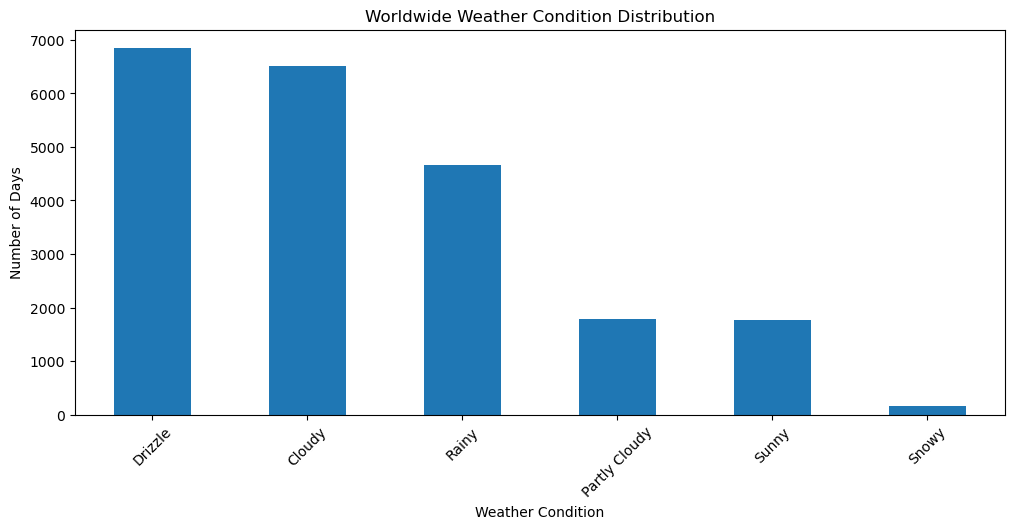

In [95]:
import matplotlib.pyplot as plt

weather_dataset["weather_condition"].value_counts().plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Worldwide Weather Condition Distribution")
plt.xlabel("Weather Condition")
plt.ylabel("Number of Days")
plt.xticks(rotation=45)
plt.show()

In [96]:
weather_dataset = weather_dataset.sort_values(
    ["city", "date"]
).reset_index(drop=True)

weather_dataset["target_weather"] = (
    weather_dataset
    .groupby("city")["weather_condition"]
    .shift(-1)
)

weather_dataset = weather_dataset.dropna(
    subset=["target_weather"]
).reset_index(drop=True)

print("Target created.")
print(
    weather_dataset["target_weather"]
    .value_counts()
)

Target created.
target_weather
Drizzle          6844
Cloudy           6507
Rainy            4665
Partly Cloudy    1780
Sunny            1761
Snowy             163
Name: count, dtype: int64


In [97]:
weather_dataset["weather_code_lag_1"] = (
    weather_dataset
    .groupby("city")["weather_code"]
    .shift(1)
)

weather_dataset["weather_code_lag_2"] = (
    weather_dataset
    .groupby("city")["weather_code"]
    .shift(2)
)

weather_dataset["rain_lag_1"] = (
    weather_dataset
    .groupby("city")["rain_sum"]
    .shift(1)
)

weather_dataset["rain_lag_2"] = (
    weather_dataset
    .groupby("city")["rain_sum"]
    .shift(2)
)

weather_dataset["precip_lag_1"] = (
    weather_dataset
    .groupby("city")["precipitation_sum"]
    .shift(1)
)

weather_dataset["wind_lag_1"] = (
    weather_dataset
    .groupby("city")["wind_speed_10m_max"]
    .shift(1)
)

weather_dataset["snow_lag_1"] = (
    weather_dataset
    .groupby("city")["snowfall_sum"]
    .shift(1)
)

In [98]:
classification_features = [
    "latitude",
    "longitude",

    "month",
    "day_of_year",
    "month_sin",
    "month_cos",
    "day_sin",
    "day_cos",

    # Current weather
    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",
    "precipitation_sum",
    "rain_sum",
    "snowfall_sum",
    "wind_speed_10m_max",
    "wind_gusts_10m_max",

    # Previous weather
    "temp_lag_1",
    "temp_lag_2",
    "temp_lag_3",
    "temp_rolling_3",
    "temp_rolling_7",

    "weather_code_lag_1",
    "weather_code_lag_2",

    "rain_lag_1",
    "rain_lag_2",
    "precip_lag_1",

    "wind_lag_1",
    "snow_lag_1"
]

# Remove rows missing required features
classification_df = weather_dataset.dropna(
    subset=classification_features + ["target_weather"]
).copy()

X = classification_df[classification_features]
y = classification_df["target_weather"]

print("Samples:", len(X))
print("Features:", len(classification_features))
print("Classes:")
print(y.value_counts())

Samples: 21696
Features: 28
Classes:
target_weather
Drizzle          6836
Cloudy           6502
Rainy            4657
Partly Cloudy    1778
Sunny            1760
Snowy             163
Name: count, dtype: int64


In [99]:
train_data = classification_df[
    classification_df["date"] < "2024-01-01"
]

test_data = classification_df[
    classification_df["date"] >= "2024-01-01"
]

X_train = train_data[classification_features]
y_train = train_data["target_weather"]

X_test = test_data[classification_features]
y_test = test_data["target_weather"]

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 17340
Testing samples : 4356


In [100]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

weather_classifier = RandomForestClassifier(
    n_estimators=400,
    max_depth=25,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

weather_classifier.fit(
    X_train,
    y_train
)

print("🌦️ Weather classifier trained!")

🌦️ Weather classifier trained!


In [101]:
y_pred = weather_classifier.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("=" * 50)
print("🌍 WORLDWIDE WEATHER CLASSIFIER")
print("=" * 50)

print(
    f"Accuracy: {accuracy * 100:.2f}%"
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

🌍 WORLDWIDE WEATHER CLASSIFIER
Accuracy: 50.76%

Classification Report:
               precision    recall  f1-score   support

       Cloudy       0.50      0.59      0.54      1344
      Drizzle       0.48      0.53      0.50      1289
Partly Cloudy       0.27      0.16      0.20       323
        Rainy       0.64      0.52      0.57       992
        Snowy       0.22      0.09      0.12        47
        Sunny       0.52      0.46      0.49       361

     accuracy                           0.51      4356
    macro avg       0.44      0.39      0.40      4356
 weighted avg       0.51      0.51      0.50      4356



In [102]:
def predict_weather_condition(country, city, prediction_date):

    print("\n" + "=" * 55)
    print("🌍 AI WEATHER CONDITION PREDICTOR")
    print("=" * 55)

    # --------------------------------
    # 1. Date
    # --------------------------------
    try:
        target_date = datetime.strptime(
            prediction_date,
            "%Y-%m-%d"
        ).date()
    except ValueError:
        return "❌ Use date format YYYY-MM-DD"

    # --------------------------------
    # 2. Geocode
    # --------------------------------
    geocode_url = (
        "https://geocoding-api.open-meteo.com/v1/search"
    )

    params = {
        "name": city,
        "count": 10,
        "language": "en",
        "format": "json"
    }

    response = requests.get(
        geocode_url,
        params=params,
        timeout=30
    )

    results = response.json().get("results", [])

    matches = [
        r for r in results
        if r.get("country", "").lower()
        == country.lower()
    ]

    if not matches:
        return f"❌ Cannot find {city}, {country}"

    location = matches[0]

    lat = location["latitude"]
    lon = location["longitude"]
    timezone = location.get("timezone", "auto")

    print(f"📍 {city}, {country}")
    print(f"🌐 {lat:.4f}, {lon:.4f}")
    print(f"📅 Prediction date: {prediction_date}")

    # --------------------------------
    # 3. Previous weather
    # --------------------------------

    previous_day = target_date - pd.Timedelta(days=1)

    # Get enough data for rolling features
    start_day = target_date - pd.Timedelta(days=10)

    url = (
        "https://archive-api.open-meteo.com/v1/archive"
    )

    params = {
        "latitude": lat,
        "longitude": lon,

        "start_date":
            start_day.strftime("%Y-%m-%d"),

        "end_date":
            previous_day.strftime("%Y-%m-%d"),

        "daily": ",".join([
            "weather_code",
            "temperature_2m_mean",
            "temperature_2m_max",
            "temperature_2m_min",
            "precipitation_sum",
            "rain_sum",
            "snowfall_sum",
            "wind_speed_10m_max",
            "wind_gusts_10m_max"
        ]),

        "timezone": timezone
    }

    response = requests.get(
        url,
        params=params,
        timeout=60
    )

    if response.status_code != 200:
        print(response.text[:500])
        return "❌ Historical weather unavailable."

    data = response.json()

    df = pd.DataFrame(data["daily"])

    if len(df) < 7:
        return "❌ Not enough previous weather data."

    df["time"] = pd.to_datetime(df["time"])

    df = df.sort_values(
        "time"
    ).reset_index(drop=True)

    # --------------------------------
    # 4. Historical features
    # --------------------------------

    temp = df["temperature_2m_mean"]

    temp_lag_1 = temp.iloc[-1]
    temp_lag_2 = temp.iloc[-2]
    temp_lag_3 = temp.iloc[-3]

    temp_rolling_3 = temp.iloc[-3:].mean()
    temp_rolling_7 = temp.iloc[-7:].mean()

    weather_code_lag_1 = (
        df["weather_code"].iloc[-1]
    )

    weather_code_lag_2 = (
        df["weather_code"].iloc[-2]
    )

    rain_lag_1 = df["rain_sum"].iloc[-1]
    rain_lag_2 = df["rain_sum"].iloc[-2]

    precip_lag_1 = (
        df["precipitation_sum"].iloc[-1]
    )

    wind_lag_1 = (
        df["wind_speed_10m_max"].iloc[-1]
    )

    snow_lag_1 = (
        df["snowfall_sum"].iloc[-1]
    )

    # --------------------------------
    # 5. Calendar
    # --------------------------------

    month = target_date.month

    day_of_year = (
        target_date.timetuple().tm_yday
    )

    month_sin = np.sin(
        2 * np.pi * month / 12
    )

    month_cos = np.cos(
        2 * np.pi * month / 12
    )

    day_sin = np.sin(
        2 * np.pi * day_of_year / 365
    )

    day_cos = np.cos(
        2 * np.pi * day_of_year / 365
    )

    # --------------------------------
    # 6. Build input
    # --------------------------------

    row = {
        "latitude": lat,
        "longitude": lon,

        "month": month,
        "day_of_year": day_of_year,

        "month_sin": month_sin,
        "month_cos": month_cos,
        "day_sin": day_sin,
        "day_cos": day_cos,

        "temperature_2m_mean":
            df["temperature_2m_mean"].iloc[-1],

        "temperature_2m_max":
            df["temperature_2m_max"].iloc[-1],

        "temperature_2m_min":
            df["temperature_2m_min"].iloc[-1],

        "precipitation_sum":
            df["precipitation_sum"].iloc[-1],

        "rain_sum":
            df["rain_sum"].iloc[-1],

        "snowfall_sum":
            df["snowfall_sum"].iloc[-1],

        "wind_speed_10m_max":
            df["wind_speed_10m_max"].iloc[-1],

        "wind_gusts_10m_max":
            df["wind_gusts_10m_max"].iloc[-1],

        "temp_lag_1": temp_lag_1,
        "temp_lag_2": temp_lag_2,
        "temp_lag_3": temp_lag_3,

        "temp_rolling_3": temp_rolling_3,
        "temp_rolling_7": temp_rolling_7,

        "weather_code_lag_1":
            weather_code_lag_1,

        "weather_code_lag_2":
            weather_code_lag_2,

        "rain_lag_1": rain_lag_1,
        "rain_lag_2": rain_lag_2,

        "precip_lag_1": precip_lag_1,

        "wind_lag_1": wind_lag_1,

        "snow_lag_1": snow_lag_1
    }

    input_df = pd.DataFrame([row])

    input_df = input_df[
        classification_features
    ]

    # --------------------------------
    # 7. ML prediction
    # --------------------------------

    prediction = weather_classifier.predict(
        input_df
    )[0]

    probabilities = (
        weather_classifier.predict_proba(
            input_df
        )[0]
    )

    probability_table = pd.DataFrame({
        "Weather":
            weather_classifier.classes_,

        "Probability":
            probabilities * 100
    })

    probability_table = (
        probability_table
        .sort_values(
            "Probability",
            ascending=False
        )
        .reset_index(drop=True)
    )

    # --------------------------------
    # 8. Emoji
    # --------------------------------

    emojis = {
        "Sunny": "☀️",
        "Partly Cloudy": "🌤️",
        "Cloudy": "☁️",
        "Foggy": "🌫️",
        "Drizzle": "🌦️",
        "Rainy": "🌧️",
        "Rain Showers": "🌧️",
        "Snowy": "❄️",
        "Snow Showers": "🌨️",
        "Thunderstorm": "⛈️",
        "Thunderstorm + Hail": "⛈️"
    }

    icon = emojis.get(
        prediction,
        "🌦️"
    )

    confidence = probability_table.iloc[0][
        "Probability"
    ]

    # --------------------------------
    # 9. Output
    # --------------------------------

    print("\n" + "=" * 55)

    print(
        f"{icon} PREDICTED WEATHER: "
        f"{prediction.upper()}"
    )

    print(
        f"🤖 Model confidence: "
        f"{confidence:.2f}%"
    )

    print("=" * 55)

    print("\nPrediction probabilities:\n")

    print(
        probability_table
        .head(5)
        .to_string(index=False)
    )

    return {
        "country": country,
        "city": city,
        "date": prediction_date,
        "weather": prediction,
        "confidence": float(
            round(confidence, 2)
        ),
        "probabilities":
            probability_table
    }

In [103]:
result = predict_weather_condition(
    "India",
    "Mumbai",
    "2024-07-15"
)


🌍 AI WEATHER CONDITION PREDICTOR
📍 Mumbai, India
🌐 19.0728, 72.8826
📅 Prediction date: 2024-07-15

🌧️ PREDICTED WEATHER: RAINY
🤖 Model confidence: 96.82%

Prediction probabilities:

      Weather  Probability
        Rainy    96.824102
      Drizzle     3.175898
       Cloudy     0.000000
Partly Cloudy     0.000000
        Snowy     0.000000


In [104]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import random

# Select 20 random test samples
sample_test = test_data.sample(
    n=min(20, len(test_data)),
    random_state=42
)

results = []

for _, row in sample_test.iterrows():

    city = row["city"]
    country = row["country"]
    date = row["date"].strftime("%Y-%m-%d")

    try:
        result = predict_weather_condition(
            country,
            city,
            date
        )

        if isinstance(result, dict):

            predicted = result["weather"]

            results.append({
                "country": country,
                "city": city,
                "date": date,
                "actual": row["target_weather"],
                "predicted": predicted,
                "confidence": result["confidence"]
            })

    except Exception as e:
        print(
            f"❌ Failed: {city} {date} -> {e}"
        )

results_df = pd.DataFrame(results)

results_df


🌍 AI WEATHER CONDITION PREDICTOR
📍 Melbourne, Australia
🌐 -37.8140, 144.9633
📅 Prediction date: 2024-09-26

🌦️ PREDICTED WEATHER: DRIZZLE
🤖 Model confidence: 63.46%

Prediction probabilities:

      Weather  Probability
      Drizzle    63.462208
        Rainy    20.502132
       Cloudy    11.409067
Partly Cloudy     3.916147
        Sunny     0.710446

🌍 AI WEATHER CONDITION PREDICTOR
📍 London, United Kingdom
🌐 51.5085, -0.1257
📅 Prediction date: 2024-10-31

☁️ PREDICTED WEATHER: CLOUDY
🤖 Model confidence: 40.61%

Prediction probabilities:

      Weather  Probability
       Cloudy    40.605736
      Drizzle    34.152205
        Rainy     9.400324
Partly Cloudy     8.264521
        Sunny     7.577213

🌍 AI WEATHER CONDITION PREDICTOR
📍 Melbourne, Australia
🌐 -37.8140, 144.9633
📅 Prediction date: 2024-06-06

☁️ PREDICTED WEATHER: CLOUDY
🤖 Model confidence: 37.40%

Prediction probabilities:

      Weather  Probability
       Cloudy    37.396399
      Drizzle    35.674670
        Rainy  

,country,city,date,actual,predicted,confidence
0,Australia,Melbourne,2024-09-26,Cloudy,Drizzle,63.46
1,United Kingdom,London,2024-10-31,Cloudy,Cloudy,40.61
2,Australia,Melbourne,2024-06-06,Drizzle,Cloudy,37.40
3,United Kingdom,London,2024-08-08,Cloudy,Cloudy,49.15
4,South Korea,Seoul,2024-08-19,Rainy,Rainy,62.69
5,United Kingdom,London,2024-09-29,Rainy,Cloudy,40.83
6,Argentina,Buenos Aires,2024-06-24,Drizzle,Drizzle,40.96
7,India,Delhi,2024-07-04,Drizzle,Rainy,53.22
8,India,Delhi,2024-04-22,Partly Cloudy,Cloudy,42.14
9,United Kingdom,London,2024-09-24,Rainy,Rainy,47.20


In [105]:
if len(results_df) > 0:

    test_accuracy = accuracy_score(
        results_df["actual"],
        results_df["predicted"]
    )

    print(
        f"🌍 Test Accuracy: "
        f"{test_accuracy * 100:.2f}%"
    )

    print("\nActual vs Predicted:")

    display(
        results_df[
            [
                "city",
                "date",
                "actual",
                "predicted",
                "confidence"
            ]
        ]
    )

🌍 Test Accuracy: 50.00%

Actual vs Predicted:


,city,date,actual,predicted,confidence
0,Melbourne,2024-09-26,Cloudy,Drizzle,63.46
1,London,2024-10-31,Cloudy,Cloudy,40.61
2,Melbourne,2024-06-06,Drizzle,Cloudy,37.40
3,London,2024-08-08,Cloudy,Cloudy,49.15
4,Seoul,2024-08-19,Rainy,Rainy,62.69
5,London,2024-09-29,Rainy,Cloudy,40.83
6,Buenos Aires,2024-06-24,Drizzle,Drizzle,40.96
7,Delhi,2024-07-04,Drizzle,Rainy,53.22
8,Delhi,2024-04-22,Partly Cloudy,Cloudy,42.14
9,London,2024-09-24,Rainy,Rainy,47.20


In [106]:
labels = sorted(
    set(results_df["actual"]) |
    set(results_df["predicted"])
)

cm = confusion_matrix(
    results_df["actual"],
    results_df["predicted"],
    labels=labels
)

cm_df = pd.DataFrame(
    cm,
    index=labels,
    columns=labels
)

print("Confusion Matrix:")
display(cm_df)

Confusion Matrix:


,Cloudy,Drizzle,Partly Cloudy,Rainy,Sunny
Cloudy,5,2,0,0,0
Drizzle,2,1,0,2,0
Partly Cloudy,1,1,1,0,0
Rainy,1,0,0,3,0
Sunny,1,0,0,0,0


In [107]:
import joblib

joblib.dump(
    weather_classifier,
    "worldwide_weather_classifier.pkl"
)

joblib.dump(
    weather_model,
    "worldwide_temperature_model.pkl"
)

print("✅ Models saved successfully.")

✅ Models saved successfully.


In [108]:
def simplify_weather(code):

    if pd.isna(code):
        return "Unknown"

    code = int(code)

    # Sunny
    if code == 0:
        return "Sunny"

    # Cloudy
    elif code in [1, 2, 3]:
        return "Cloudy"

    # Fog → Cloudy
    elif code in [45, 48]:
        return "Cloudy"

    # Drizzle / Rain / Rain showers
    elif code in [
        51, 53, 55, 56, 57,
        61, 63, 65, 66, 67,
        80, 81, 82
    ]:
        return "Rainy"

    # Snow
    elif code in [71, 73, 75, 77, 85, 86]:
        return "Snowy"

    # Thunderstorm
    elif code in [95, 96, 99]:
        return "Thunderstorm"

    return "Cloudy"


weather_dataset["weather_class"] = (
    weather_dataset["weather_code"]
    .apply(simplify_weather)
)

print(
    weather_dataset["weather_class"]
    .value_counts()
)

weather_class
Rainy     11513
Cloudy     8282
Sunny      1762
Snowy       163
Name: count, dtype: int64


In [109]:
weather_dataset = weather_dataset.sort_values(
    ["city", "date"]
).reset_index(drop=True)

weather_dataset["target_class"] = (
    weather_dataset
    .groupby("city")["weather_class"]
    .shift(-1)
)

weather_dataset = weather_dataset.dropna(
    subset=["target_class"]
).reset_index(drop=True)

print(
    weather_dataset["target_class"]
    .value_counts()
)

target_class
Rainy     11506
Cloudy     8278
Sunny      1761
Snowy       163
Name: count, dtype: int64


In [110]:
classification_df = weather_dataset.dropna(
    subset=classification_features
).copy()

train_data = classification_df[
    classification_df["date"] < "2024-01-01"
]

test_data = classification_df[
    classification_df["date"] >= "2024-01-01"
]

X_train = train_data[classification_features]
y_train = train_data["target_class"]

X_test = test_data[classification_features]
y_test = test_data["target_class"]

weather_classifier_v2 = RandomForestClassifier(
    n_estimators=500,
    max_depth=25,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

weather_classifier_v2.fit(
    X_train,
    y_train
)

y_pred = weather_classifier_v2.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"New Accuracy: {accuracy * 100:.2f}%"
)

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

New Accuracy: 69.82%
              precision    recall  f1-score   support

      Cloudy       0.61      0.66      0.63      1658
       Rainy       0.78      0.79      0.79      2278
       Snowy       0.33      0.11      0.16        47
       Sunny       0.58      0.34      0.43       361

    accuracy                           0.70      4344
   macro avg       0.58      0.48      0.50      4344
weighted avg       0.69      0.70      0.69      4344



In [111]:
print(
    weather_dataset.groupby(
        "weather_class"
    )["weather_code"]
    .value_counts()
)

weather_class  weather_code
Cloudy         3               6496
               1                965
               2                816
Rainy          51              4389
               63              2387
               53              1764
               61              1622
               55               689
               65               655
Snowy          73                76
               71                64
               75                23
Sunny          0               1762
Name: count, dtype: int64


In [112]:
print(
    weather_dataset[
        weather_dataset["weather_class"] == "Thunderstorm"
    ][
        ["city", "country", "date", "weather_code"]
    ].head(20)
)

Empty DataFrame
Columns: [city, country, date, weather_code]
Index: []


In [113]:
class_counts = (
    weather_dataset["weather_class"]
    .value_counts()
    .sort_values(ascending=False)
)

print(class_counts)

print("\nPercentage distribution:")
print(
    (class_counts / len(weather_dataset) * 100)
    .round(2)
)

weather_class
Rainy     11506
Cloudy     8277
Sunny      1762
Snowy       163
Name: count, dtype: int64

Percentage distribution:
weather_class
Rainy     53.00
Cloudy    38.13
Sunny      8.12
Snowy      0.75
Name: count, dtype: float64


In [114]:
code_distribution = (
    weather_dataset
    .groupby(["weather_class", "weather_code"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(code_distribution)

,weather_class,weather_code,count
2,Cloudy,3,6496
3,Rainy,51,4389
7,Rainy,63,2387
4,Rainy,53,1764
12,Sunny,0,1762
6,Rainy,61,1622
0,Cloudy,1,965
1,Cloudy,2,816
5,Rainy,55,689
8,Rainy,65,655


In [115]:
thunderstorm_df = weather_dataset[
    weather_dataset["weather_code"].isin(
        [95, 96, 99]
    )
]

print(
    "Thunderstorm samples:",
    len(thunderstorm_df)
)

display(
    thunderstorm_df[
        [
            "city",
            "country",
            "date",
            "weather_code"
        ]
    ].head(30)
)

Thunderstorm samples: 0


,city,country,date,weather_code


In [116]:
print(
    test_data["target_class"]
    .value_counts()
)

target_class
Rainy     2278
Cloudy    1658
Sunny      361
Snowy       47
Name: count, dtype: int64


In [117]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

weather_classifier_final = RandomForestClassifier(
    n_estimators=700,
    max_depth=30,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

weather_classifier_final.fit(
    X_train,
    y_train
)

y_pred = weather_classifier_final.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

print("=" * 55)
print("🌍 FINAL WEATHER CLASSIFIER")
print("=" * 55)

print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Macro F1 : {macro_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

🌍 FINAL WEATHER CLASSIFIER
Accuracy : 69.89%
Macro F1 : 0.4896

Classification Report:
              precision    recall  f1-score   support

      Cloudy       0.61      0.66      0.63      1658
       Rainy       0.78      0.80      0.79      2278
       Snowy       0.33      0.06      0.11        47
       Sunny       0.58      0.34      0.43       361

    accuracy                           0.70      4344
   macro avg       0.58      0.47      0.49      4344
weighted avg       0.69      0.70      0.69      4344



In [118]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

weather_classifier_final = RandomForestClassifier(
    n_estimators=700,
    max_depth=30,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

weather_classifier_final.fit(
    X_train,
    y_train
)

y_pred = weather_classifier_final.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

print("=" * 55)
print("🌍 FINAL WEATHER CLASSIFIER")
print("=" * 55)

print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Macro F1 : {macro_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

🌍 FINAL WEATHER CLASSIFIER
Accuracy : 69.89%
Macro F1 : 0.4896

Classification Report:
              precision    recall  f1-score   support

      Cloudy       0.61      0.66      0.63      1658
       Rainy       0.78      0.80      0.79      2278
       Snowy       0.33      0.06      0.11        47
       Sunny       0.58      0.34      0.43       361

    accuracy                           0.70      4344
   macro avg       0.58      0.47      0.49      4344
weighted avg       0.69      0.70      0.69      4344



In [119]:
importance_df = pd.DataFrame({
    "feature": classification_features,
    "importance":
        weather_classifier_final.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(importance_df.head(15))

,feature,importance
0,temp_rolling_7,0.082367
1,temp_rolling_3,0.070258
2,temperature_2m_min,0.067585
3,temperature_2m_max,0.064288
4,temperature_2m_mean,0.063232
5,temp_lag_3,0.058345
6,precipitation_sum,0.056192
7,temp_lag_1,0.052035
8,rain_sum,0.050111
9,temp_lag_2,0.048094


In [120]:
joblib.dump(
    weather_classifier_final,
    "worldwide_weather_classifier_final.pkl"
)

print("✅ Final classifier saved.")

✅ Final classifier saved.


In [121]:
weather_classifier

RandomForestClassifier(class_weight='balanced', max_depth=25,
                       min_samples_leaf=2, n_estimators=400, n_jobs=-1,
                       random_state=42)

In [122]:
weather_classifier_final

RandomForestClassifier(class_weight='balanced_subsample', max_depth=30,
                       min_samples_leaf=2, min_samples_split=4,
                       n_estimators=700, n_jobs=-1, random_state=42)

In [123]:
weather_classifier.classes_

array(['Cloudy', 'Drizzle', 'Partly Cloudy', 'Rainy', 'Snowy', 'Sunny'],
      dtype=object)

In [124]:
weather_classifier_final.classes_

array(['Cloudy', 'Rainy', 'Snowy', 'Sunny'], dtype=object)

In [125]:
y_pred_final = weather_classifier_final.predict(X_test)

accuracy_final = accuracy_score(
    y_test,
    y_pred_final
)

macro_f1_final = f1_score(
    y_test,
    y_pred_final,
    average="macro"
)

print("=" * 50)
print("🌍 FINAL WEATHER CLASSIFIER")
print("=" * 50)
print(f"Accuracy : {accuracy_final * 100:.2f}%")
print(f"Macro F1 : {macro_f1_final:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_final,
        zero_division=0
    )
)

🌍 FINAL WEATHER CLASSIFIER
Accuracy : 69.89%
Macro F1 : 0.4896

Classification Report:
              precision    recall  f1-score   support

      Cloudy       0.61      0.66      0.63      1658
       Rainy       0.78      0.80      0.79      2278
       Snowy       0.33      0.06      0.11        47
       Sunny       0.58      0.34      0.43       361

    accuracy                           0.70      4344
   macro avg       0.58      0.47      0.49      4344
weighted avg       0.69      0.70      0.69      4344



In [126]:
y_pred_final = weather_classifier_final.predict(X_test)

accuracy_final = accuracy_score(
    y_test,
    y_pred_final
)

macro_f1_final = f1_score(
    y_test,
    y_pred_final,
    average="macro"
)

print("=" * 50)
print("🌍 FINAL WEATHER CLASSIFIER")
print("=" * 50)
print(f"Accuracy : {accuracy_final * 100:.2f}%")
print(f"Macro F1 : {macro_f1_final:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_final,
        zero_division=0
    )
)

🌍 FINAL WEATHER CLASSIFIER
Accuracy : 69.89%
Macro F1 : 0.4896

Classification Report:
              precision    recall  f1-score   support

      Cloudy       0.61      0.66      0.63      1658
       Rainy       0.78      0.80      0.79      2278
       Snowy       0.33      0.06      0.11        47
       Sunny       0.58      0.34      0.43       361

    accuracy                           0.70      4344
   macro avg       0.58      0.47      0.49      4344
weighted avg       0.69      0.70      0.69      4344



In [127]:
def predict_weather_condition(country, city, prediction_date):

    try:
        target_date = datetime.strptime(
            prediction_date,
            "%Y-%m-%d"
        ).date()
    except ValueError:
        print("❌ Date must be YYYY-MM-DD")
        return None

    # -----------------------------
    # Geocoding
    # -----------------------------
    geocode_url = "https://geocoding-api.open-meteo.com/v1/search"

    response = requests.get(
        geocode_url,
        params={
            "name": city,
            "count": 10,
            "language": "en",
            "format": "json"
        },
        timeout=30
    )

    if response.status_code != 200:
        print("❌ Geocoding failed.")
        return None

    results = response.json().get("results", [])

    matches = [
        r for r in results
        if r.get("country", "").lower() == country.lower()
    ]

    if not matches:
        print(f"❌ {city} not found in {country}")
        return None

    location = matches[0]

    lat = location["latitude"]
    lon = location["longitude"]
    timezone = location.get("timezone", "auto")

    # -----------------------------
    # Get previous weather
    # -----------------------------
    start_date = target_date - pd.Timedelta(days=10)
    previous_date = target_date - pd.Timedelta(days=1)

    archive_url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date.strftime("%Y-%m-%d"),
        "end_date": previous_date.strftime("%Y-%m-%d"),
        "daily": (
            "weather_code,"
            "temperature_2m_mean,"
            "temperature_2m_max,"
            "temperature_2m_min,"
            "precipitation_sum,"
            "rain_sum,"
            "snowfall_sum,"
            "wind_speed_10m_max,"
            "wind_gusts_10m_max"
        ),
        "timezone": timezone
    }

    response = requests.get(
        archive_url,
        params=params,
        timeout=60
    )

    if response.status_code != 200:
        print("❌ Historical weather request failed.")
        print(response.text[:500])
        return None

    df = pd.DataFrame(
        response.json()["daily"]
    )

    if len(df) < 7:
        print("❌ Not enough historical data.")
        return None

    df["time"] = pd.to_datetime(df["time"])
    df = df.sort_values("time").reset_index(drop=True)

    # -----------------------------
    # Feature engineering
    # -----------------------------
    temp = df["temperature_2m_mean"]

    month = target_date.month
    day_of_year = target_date.timetuple().tm_yday

    input_row = {

        "latitude": lat,
        "longitude": lon,

        "month": month,
        "day_of_year": day_of_year,

        "month_sin":
            np.sin(2 * np.pi * month / 12),

        "month_cos":
            np.cos(2 * np.pi * month / 12),

        "day_sin":
            np.sin(2 * np.pi * day_of_year / 365),

        "day_cos":
            np.cos(2 * np.pi * day_of_year / 365),

        "temperature_2m_mean":
            df["temperature_2m_mean"].iloc[-1],

        "temperature_2m_max":
            df["temperature_2m_max"].iloc[-1],

        "temperature_2m_min":
            df["temperature_2m_min"].iloc[-1],

        "precipitation_sum":
            df["precipitation_sum"].iloc[-1],

        "rain_sum":
            df["rain_sum"].iloc[-1],

        "snowfall_sum":
            df["snowfall_sum"].iloc[-1],

        "wind_speed_10m_max":
            df["wind_speed_10m_max"].iloc[-1],

        "wind_gusts_10m_max":
            df["wind_gusts_10m_max"].iloc[-1],

        "temp_lag_1":
            temp.iloc[-1],

        "temp_lag_2":
            temp.iloc[-2],

        "temp_lag_3":
            temp.iloc[-3],

        "temp_rolling_3":
            temp.iloc[-3:].mean(),

        "temp_rolling_7":
            temp.iloc[-7:].mean(),

        "weather_code_lag_1":
            df["weather_code"].iloc[-1],

        "weather_code_lag_2":
            df["weather_code"].iloc[-2],

        "rain_lag_1":
            df["rain_sum"].iloc[-1],

        "rain_lag_2":
            df["rain_sum"].iloc[-2],

        "precip_lag_1":
            df["precipitation_sum"].iloc[-1],

        "wind_lag_1":
            df["wind_speed_10m_max"].iloc[-1],

        "snow_lag_1":
            df["snowfall_sum"].iloc[-1]
    }

    # THIS is the input dataframe
    input_df = pd.DataFrame([input_row])

    # Match training feature order
    input_df = input_df[
        classification_features
    ]

    # -----------------------------
    # ML prediction
    # -----------------------------
    prediction = weather_classifier_final.predict(
        input_df
    )[0]

    probabilities = (
        weather_classifier_final
        .predict_proba(input_df)[0]
    )

    probability_df = pd.DataFrame({
        "Weather": weather_classifier_final.classes_,
        "Probability": probabilities * 100
    }).sort_values(
        "Probability",
        ascending=False
    ).reset_index(drop=True)

    confidence = probability_df.iloc[0]["Probability"]

    emojis = {
        "Sunny": "☀️",
        "Cloudy": "☁️",
        "Rainy": "🌧️",
        "Snowy": "❄️",
        "Thunderstorm": "⛈️"
    }

    print("\n" + "=" * 50)
    print("🌍 WORLDWIDE AI WEATHER PREDICTION")
    print("=" * 50)

    print(f"Country    : {country}")
    print(f"City       : {city}")
    print(f"Date       : {prediction_date}")

    print(
        f"\n{emojis.get(prediction, '🌦️')} "
        f"Prediction : {prediction}"
    )

    print(
        f"🤖 Confidence: {confidence:.2f}%"
    )

    print("\nProbability:")
    display(probability_df)

    return {
        "country": country,
        "city": city,
        "date": prediction_date,
        "prediction": prediction,
        "confidence": float(round(confidence, 2)),
        "probabilities": probability_df
    }

In [128]:
result = predict_weather_condition(
    "India",
    "Mumbai",
    "2024-07-15"
)


🌍 WORLDWIDE AI WEATHER PREDICTION
Country    : India
City       : Mumbai
Date       : 2024-07-15

🌧️ Prediction : Rainy
🤖 Confidence: 99.92%

Probability:


,Weather,Probability
0,Rainy,99.91612
1,Cloudy,0.08388
2,Snowy,0.00000
3,Sunny,0.00000


In [129]:
def predict_next_day_condition(df, target_date, lat, lon):

    target_date = pd.to_datetime(target_date).date()

    temp = df["temperature_2m_mean"]

    month = target_date.month
    day_of_year = target_date.timetuple().tm_yday

    input_row = {
        "latitude": lat,
        "longitude": lon,

        "month": month,
        "day_of_year": day_of_year,

        "month_sin": np.sin(
            2 * np.pi * month / 12
        ),

        "month_cos": np.cos(
            2 * np.pi * month / 12
        ),

        "day_sin": np.sin(
            2 * np.pi * day_of_year / 365
        ),

        "day_cos": np.cos(
            2 * np.pi * day_of_year / 365
        ),

        "temperature_2m_mean":
            df["temperature_2m_mean"].iloc[-1],

        "temperature_2m_max":
            df["temperature_2m_max"].iloc[-1],

        "temperature_2m_min":
            df["temperature_2m_min"].iloc[-1],

        "precipitation_sum":
            df["precipitation_sum"].iloc[-1],

        "rain_sum":
            df["rain_sum"].iloc[-1],

        "snowfall_sum":
            df["snowfall_sum"].iloc[-1],

        "wind_speed_10m_max":
            df["wind_speed_10m_max"].iloc[-1],

        "wind_gusts_10m_max":
            df["wind_gusts_10m_max"].iloc[-1],

        "temp_lag_1": temp.iloc[-1],
        "temp_lag_2": temp.iloc[-2],
        "temp_lag_3": temp.iloc[-3],

        "temp_rolling_3":
            temp.iloc[-3:].mean(),

        "temp_rolling_7":
            temp.iloc[-7:].mean(),

        "weather_code_lag_1":
            df["weather_code"].iloc[-1],

        "weather_code_lag_2":
            df["weather_code"].iloc[-2],

        "rain_lag_1":
            df["rain_sum"].iloc[-1],

        "rain_lag_2":
            df["rain_sum"].iloc[-2],

        "precip_lag_1":
            df["precipitation_sum"].iloc[-1],

        "wind_lag_1":
            df["wind_speed_10m_max"].iloc[-1],

        "snow_lag_1":
            df["snowfall_sum"].iloc[-1]
    }

    input_df = pd.DataFrame([input_row])

    input_df = input_df[
        classification_features
    ]

    prediction = weather_classifier_final.predict(
        input_df
    )[0]

    probabilities = weather_classifier_final.predict_proba(
        input_df
    )[0]

    confidence = max(probabilities) * 100

    return prediction, confidence

In [130]:
# Example:
# df should contain the latest historical observations

prediction, confidence = predict_next_day_condition(
    df,
    "2024-07-16",
    lat,
    lon
)

print("Prediction:", prediction)
print("Confidence:", round(confidence, 2), "%")

NameError: name 'lat' is not defined

In [131]:
# Get Mumbai coordinates
lat = 19.0760
lon = 72.8777

# Get historical data up to the day before prediction
url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": lat,
    "longitude": lon,
    "start_date": "2024-07-09",
    "end_date": "2024-07-15",
    "daily": ",".join([
        "weather_code",
        "temperature_2m_mean",
        "temperature_2m_max",
        "temperature_2m_min",
        "precipitation_sum",
        "rain_sum",
        "snowfall_sum",
        "wind_speed_10m_max",
        "wind_gusts_10m_max"
    ]),
    "timezone": "Asia/Kolkata"
}

response = requests.get(
    url,
    params=params,
    timeout=60
)

print("Status:", response.status_code)

data = response.json()

df = pd.DataFrame(data["daily"])

print("\nHistorical data:")
display(df)


Status: 200

Historical data:


,time,weather_code,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,rain_sum,snowfall_sum,wind_speed_10m_max,wind_gusts_10m_max
0,2024-07-09,65,26.1,27.0,25.5,80.2,80.2,0.0,22.1,42.1
1,2024-07-10,65,26.6,28.8,25.2,36.0,36.0,0.0,21.3,41.4
2,2024-07-11,63,26.4,28.8,24.6,39.1,39.1,0.0,21.6,45.4
3,2024-07-12,65,26.0,26.9,25.2,83.3,83.3,0.0,21.0,43.6
4,2024-07-13,63,25.9,26.6,25.2,76.7,76.7,0.0,27.6,54.7
5,2024-07-14,63,25.6,26.6,24.5,50.5,50.5,0.0,24.5,47.2
6,2024-07-15,61,26.4,28.1,24.9,10.2,10.2,0.0,14.8,31.3


In [132]:
prediction, confidence = predict_next_day_condition(
    df,
    "2024-07-16",
    lat,
    lon
)

print("\n🌦️ Prediction:", prediction)
print("🤖 Confidence:", round(confidence, 2), "%")


🌦️ Prediction: Rainy
🤖 Confidence: 100.0 %


In [133]:
def worldwide_weather_predictor():

    print("=" * 55)
    print("🌍 WORLDWIDE AI WEATHER PREDICTOR")
    print("=" * 55)

    # -----------------------------
    # USER INPUT
    # -----------------------------
    country = input("🌍 Enter country: ").strip()
    city = input("🏙️ Enter city: ").strip()
    date_input = input(
        "📅 Enter prediction date (YYYY-MM-DD): "
    ).strip()

    try:
        target_date = datetime.strptime(
            date_input,
            "%Y-%m-%d"
        ).date()
    except ValueError:
        print("❌ Invalid date.")
        return

    # -----------------------------
    # GEOCODING
    # -----------------------------
    geocode_url = (
        "https://geocoding-api.open-meteo.com/v1/search"
    )

    response = requests.get(
        geocode_url,
        params={
            "name": city,
            "count": 10,
            "language": "en",
            "format": "json"
        },
        timeout=30
    )

    if response.status_code != 200:
        print("❌ Geocoding API failed.")
        return

    results = response.json().get("results", [])

    matches = [
        r for r in results
        if r.get("country", "").lower()
        == country.lower()
    ]

    if not matches:
        print(
            f"❌ Could not find {city}, {country}"
        )
        return

    location = matches[0]

    lat = location["latitude"]
    lon = location["longitude"]
    timezone = location.get(
        "timezone",
        "auto"
    )

    print(
        f"\n📍 Location found: "
        f"{location.get('name')}, "
        f"{location.get('country')}"
    )

    print(
        f"🌐 Coordinates: "
        f"{lat:.4f}, {lon:.4f}"
    )

    # -----------------------------
    # HISTORICAL DATA
    # -----------------------------
    previous_date = (
        target_date - pd.Timedelta(days=1)
    )

    start_date = (
        target_date - pd.Timedelta(days=10)
    )

    archive_url = (
        "https://archive-api.open-meteo.com/v1/archive"
    )

    params = {
        "latitude": lat,
        "longitude": lon,

        "start_date":
            start_date.strftime("%Y-%m-%d"),

        "end_date":
            previous_date.strftime("%Y-%m-%d"),

        "daily": ",".join([
            "weather_code",
            "temperature_2m_mean",
            "temperature_2m_max",
            "temperature_2m_min",
            "precipitation_sum",
            "rain_sum",
            "snowfall_sum",
            "wind_speed_10m_max",
            "wind_gusts_10m_max"
        ]),

        "timezone": timezone
    }

    response = requests.get(
        archive_url,
        params=params,
        timeout=60
    )

    if response.status_code != 200:
        print(
            "❌ Could not retrieve historical weather."
        )
        print(response.text[:500])
        return

    df = pd.DataFrame(
        response.json()["daily"]
    )

    if len(df) < 7:
        print("❌ Not enough historical data.")
        return

    df["time"] = pd.to_datetime(
        df["time"]
    )

    df = df.sort_values(
        "time"
    ).reset_index(drop=True)

    # -----------------------------
    # ML PREDICTION
    # -----------------------------
    prediction, confidence = (
        predict_next_day_condition(
            df,
            date_input,
            lat,
            lon
        )
    )

    # -----------------------------
    # PROBABILITIES
    # -----------------------------
    temp = df["temperature_2m_mean"]

    month = target_date.month
    day_of_year = target_date.timetuple().tm_yday

    input_row = {
        "latitude": lat,
        "longitude": lon,

        "month": month,
        "day_of_year": day_of_year,

        "month_sin":
            np.sin(2 * np.pi * month / 12),

        "month_cos":
            np.cos(2 * np.pi * month / 12),

        "day_sin":
            np.sin(2 * np.pi * day_of_year / 365),

        "day_cos":
            np.cos(2 * np.pi * day_of_year / 365),

        "temperature_2m_mean":
            temp.iloc[-1],

        "temperature_2m_max":
            df["temperature_2m_max"].iloc[-1],

        "temperature_2m_min":
            df["temperature_2m_min"].iloc[-1],

        "precipitation_sum":
            df["precipitation_sum"].iloc[-1],

        "rain_sum":
            df["rain_sum"].iloc[-1],

        "snowfall_sum":
            df["snowfall_sum"].iloc[-1],

        "wind_speed_10m_max":
            df["wind_speed_10m_max"].iloc[-1],

        "wind_gusts_10m_max":
            df["wind_gusts_10m_max"].iloc[-1],

        "temp_lag_1":
            temp.iloc[-1],

        "temp_lag_2":
            temp.iloc[-2],

        "temp_lag_3":
            temp.iloc[-3],

        "temp_rolling_3":
            temp.iloc[-3:].mean(),

        "temp_rolling_7":
            temp.iloc[-7:].mean(),

        "weather_code_lag_1":
            df["weather_code"].iloc[-1],

        "weather_code_lag_2":
            df["weather_code"].iloc[-2],

        "rain_lag_1":
            df["rain_sum"].iloc[-1],

        "rain_lag_2":
            df["rain_sum"].iloc[-2],

        "precip_lag_1":
            df["precipitation_sum"].iloc[-1],

        "wind_lag_1":
            df["wind_speed_10m_max"].iloc[-1],

        "snow_lag_1":
            df["snowfall_sum"].iloc[-1]
    }

    input_df = pd.DataFrame([input_row])

    input_df = input_df[
        classification_features
    ]

    probabilities = (
        weather_classifier_final
        .predict_proba(input_df)[0]
    )

    probability_df = pd.DataFrame({
        "Weather":
            weather_classifier_final.classes_,
        "Probability":
            probabilities * 100
    }).sort_values(
        "Probability",
        ascending=False
    )

    # -----------------------------
    # DISPLAY
    # -----------------------------
    emoji = {
        "Sunny": "☀️",
        "Cloudy": "☁️",
        "Rainy": "🌧️",
        "Snowy": "❄️",
        "Thunderstorm": "⛈️"
    }

    print("\n" + "=" * 55)
    print("🌦️ FINAL AI WEATHER PREDICTION")
    print("=" * 55)

    print(f"🌍 Country    : {country}")
    print(f"🏙️ City       : {city}")
    print(f"📅 Date       : {date_input}")

    print(
        f"\n{emoji.get(prediction, '🌦️')} "
        f"Weather     : {prediction}"
    )

    print(
        f"🤖 Confidence : "
        f"{confidence:.2f}%"
    )

    print("\n📊 Probability Distribution:")
    display(
        probability_df.reset_index(drop=True)
    )

    return {
        "country": country,
        "city": city,
        "date": date_input,
        "prediction": prediction,
        "confidence": float(
            round(confidence, 2)
        ),
        "probabilities": probability_df
    }

In [134]:
result = worldwide_weather_predictor()

🌍 WORLDWIDE AI WEATHER PREDICTOR


🌍 Enter country:  India
🏙️ Enter city:  Mumbai
📅 Enter prediction date (YYYY-MM-DD):  2025-10-20



📍 Location found: Mumbai, India
🌐 Coordinates: 19.0728, 72.8826

🌦️ FINAL AI WEATHER PREDICTION
🌍 Country    : India
🏙️ City       : Mumbai
📅 Date       : 2025-10-20

🌧️ Weather     : Rainy
🤖 Confidence : 55.04%

📊 Probability Distribution:


,Weather,Probability
0,Rainy,55.042706
1,Cloudy,38.420643
2,Sunny,6.536651
3,Snowy,0.000000


In [135]:
# Use the simplified weather classes
long_range_df = weather_dataset.copy()

# Remove unknown classes
long_range_df = long_range_df[
    long_range_df["weather_class"].isin([
        "Sunny",
        "Cloudy",
        "Rainy",
        "Snowy",
        "Thunderstorm"
    ])
].copy()

# Calendar features for the target date
long_range_df["month"] = (
    long_range_df["date"].dt.month
)

long_range_df["day_of_year"] = (
    long_range_df["date"].dt.dayofyear
)

long_range_df["month_sin"] = np.sin(
    2 * np.pi * long_range_df["month"] / 12
)

long_range_df["month_cos"] = np.cos(
    2 * np.pi * long_range_df["month"] / 12
)

long_range_df["day_sin"] = np.sin(
    2 * np.pi * long_range_df["day_of_year"] / 365
)

long_range_df["day_cos"] = np.cos(
    2 * np.pi * long_range_df["day_of_year"] / 365
)

print("Long-range dataset:", long_range_df.shape)

Long-range dataset: (21708, 43)


In [136]:
long_range_features = [
    "latitude",
    "longitude",
    "month",
    "day_of_year",
    "month_sin",
    "month_cos",
    "day_sin",
    "day_cos"
]

X_long = long_range_df[
    long_range_features
]

y_long = long_range_df[
    "weather_class"
]

long_range_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

long_range_model.fit(
    X_long,
    y_long
)

print("🌍 Long-range weather model trained!")

🌍 Long-range weather model trained!


In [137]:
def predict_long_range_weather(
    country,
    city,
    prediction_date
):

    # Geocode
    response = requests.get(
        "https://geocoding-api.open-meteo.com/v1/search",
        params={
            "name": city,
            "count": 10,
            "language": "en",
            "format": "json"
        },
        timeout=30
    )

    results = response.json().get(
        "results",
        []
    )

    matches = [
        r for r in results
        if r.get("country", "").lower()
        == country.lower()
    ]

    if not matches:
        print("❌ Location not found.")
        return None

    location = matches[0]

    lat = location["latitude"]
    lon = location["longitude"]

    date_obj = datetime.strptime(
        prediction_date,
        "%Y-%m-%d"
    ).date()

    month = date_obj.month
    day_of_year = date_obj.timetuple().tm_yday

    input_data = pd.DataFrame([{
        "latitude": lat,
        "longitude": lon,

        "month": month,
        "day_of_year": day_of_year,

        "month_sin": np.sin(
            2 * np.pi * month / 12
        ),

        "month_cos": np.cos(
            2 * np.pi * month / 12
        ),

        "day_sin": np.sin(
            2 * np.pi * day_of_year / 365
        ),

        "day_cos": np.cos(
            2 * np.pi * day_of_year / 365
        )
    }])

    prediction = long_range_model.predict(
        input_data[long_range_features]
    )[0]

    probabilities = (
        long_range_model.predict_proba(
            input_data[long_range_features]
        )[0]
    )

    probability_df = pd.DataFrame({
        "Weather":
            long_range_model.classes_,
        "Probability":
            probabilities * 100
    }).sort_values(
        "Probability",
        ascending=False
    ).reset_index(drop=True)

    confidence = probability_df.iloc[0][
        "Probability"
    ]

    emojis = {
        "Sunny": "☀️",
        "Cloudy": "☁️",
        "Rainy": "🌧️",
        "Snowy": "❄️",
        "Thunderstorm": "⛈️"
    }

    print("\n" + "=" * 55)
    print("🌍 LONG-RANGE AI WEATHER ESTIMATE")
    print("=" * 55)

    print(f"Country : {country}")
    print(f"City    : {city}")
    print(f"Date    : {prediction_date}")

    print(
        f"\n{emojis.get(prediction, '🌦️')} "
        f"Estimated weather: {prediction}"
    )

    print(
        f"🤖 Probability: "
        f"{confidence:.2f}%"
    )

    print("\nAll probabilities:")
    display(probability_df)

    return {
        "country": country,
        "city": city,
        "date": prediction_date,
        "prediction": prediction,
        "probabilities": probability_df
    }

In [138]:
result = predict_long_range_weather(
    "India",
    "Mumbai",
    "2026-10-20"
)


🌍 LONG-RANGE AI WEATHER ESTIMATE
Country : India
City    : Mumbai
Date    : 2026-10-20

🌧️ Estimated weather: Rainy
🤖 Probability: 55.81%

All probabilities:


,Weather,Probability
0,Rainy,55.81044
1,Cloudy,43.75627
2,Sunny,0.43329
3,Snowy,0.00000


In [139]:
print(long_range_model.classes_)

['Cloudy' 'Rainy' 'Snowy' 'Sunny']


In [140]:
print(
    weather_dataset["weather_class"].value_counts()
)

weather_class
Rainy     11506
Cloudy     8277
Sunny      1762
Snowy       163
Name: count, dtype: int64


In [141]:
print("Classes in long-range model:")
print(long_range_model.classes_)

Classes in long-range model:
['Cloudy' 'Rainy' 'Snowy' 'Sunny']


In [142]:
print("\nWeather classes in dataset:")
print(
    weather_dataset["weather_class"].value_counts()
)


Weather classes in dataset:
weather_class
Rainy     11506
Cloudy     8277
Sunny      1762
Snowy       163
Name: count, dtype: int64


In [143]:
print(
    weather_dataset[
        weather_dataset["weather_code"].isin([95, 96, 99])
    ][
        ["city", "country", "date", "weather_code"]
    ].head(20)
)

Empty DataFrame
Columns: [city, country, date, weather_code]
Index: []


In [144]:
long_range_df = weather_dataset[
    weather_dataset["weather_class"].isin([
        "Sunny",
        "Cloudy",
        "Rainy",
        "Snowy",
        "Thunderstorm"
    ])
].copy()

print(
    long_range_df["weather_class"].value_counts()
)

weather_class
Rainy     11506
Cloudy     8277
Sunny      1762
Snowy       163
Name: count, dtype: int64


In [145]:
X_long = long_range_df[
    long_range_features
]

y_long = long_range_df[
    "weather_class"
]

long_range_model = RandomForestClassifier(
    n_estimators=700,
    max_depth=25,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

long_range_model.fit(
    X_long,
    y_long
)

print("✅ Long-range model retrained.")
print(
    "Classes:",
    long_range_model.classes_
)

✅ Long-range model retrained.
Classes: ['Cloudy' 'Rainy' 'Snowy' 'Sunny']


In [146]:
result = predict_long_range_weather(
    "India",
    "Mumbai",
    "2026-10-20"
)


🌍 LONG-RANGE AI WEATHER ESTIMATE
Country : India
City    : Mumbai
Date    : 2026-10-20

🌧️ Estimated weather: Rainy
🤖 Probability: 55.87%

All probabilities:


,Weather,Probability
0,Rainy,55.874567
1,Cloudy,43.025874
2,Sunny,1.099558
3,Snowy,0.000000


In [147]:
print("Weather classes:")
print(weather_dataset["weather_class"].value_counts())

print("\nThunderstorm records:")
storm_data = weather_dataset[
    weather_dataset["weather_code"].isin([95, 96, 99])
]

print(storm_data[[
    "city",
    "country",
    "date",
    "weather_code",
    "weather_class"
]].head(20))

print("\nTotal thunderstorm records:", len(storm_data))

Weather classes:
weather_class
Rainy     11506
Cloudy     8277
Sunny      1762
Snowy       163
Name: count, dtype: int64

Thunderstorm records:
Empty DataFrame
Columns: [city, country, date, weather_code, weather_class]
Index: []

Total thunderstorm records: 0


In [148]:
storm_cities = [
    {"city": "Miami", "country": "USA", "lat": 25.7617, "lon": -80.1918},
    {"city": "Manila", "country": "Philippines", "lat": 14.5995, "lon": 120.9842},
    {"city": "Jakarta", "country": "Indonesia", "lat": -6.2088, "lon": 106.8456},
    {"city": "Bangkok", "country": "Thailand", "lat": 13.7563, "lon": 100.5018},
    {"city": "Dhaka", "country": "Bangladesh", "lat": 23.8103, "lon": 90.4125},
    {"city": "Lagos", "country": "Nigeria", "lat": 6.5244, "lon": 3.3792},
    {"city": "Kampala", "country": "Uganda", "lat": 0.3476, "lon": 32.5825},
    {"city": "Mexico City", "country": "Mexico", "lat": 19.4326, "lon": -99.1332},
    {"city": "Brisbane", "country": "Australia", "lat": -27.4698, "lon": 153.0251},
    {"city": "São Luís", "country": "Brazil", "lat": -2.5307, "lon": -44.3068}
]

print("Cities to add:", len(storm_cities))

Cities to add: 10


In [149]:
storm_weather_data = []

for c in storm_cities:

    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": c["lat"],
        "longitude": c["lon"],
        "start_date": "2020-01-01",
        "end_date": "2024-12-31",
        "daily": "weather_code",
        "timezone": "auto"
    }

    try:
        response = requests.get(url, params=params, timeout=30)
        data = response.json()

        if "daily" in data:

            temp = pd.DataFrame({
                "date": data["daily"]["time"],
                "weather_code": data["daily"]["weather_code"]
            })

            temp["city"] = c["city"]
            temp["country"] = c["country"]

            storm_weather_data.append(temp)

            print(f"✅ {c['city']} downloaded")

        else:
            print(f"❌ No data: {c['city']}")

    except Exception as e:
        print(f"❌ Error {c['city']}: {e}")

print("\nCompleted:", len(storm_weather_data))

✅ Miami downloaded
✅ Manila downloaded
✅ Jakarta downloaded
✅ Bangkok downloaded
✅ Dhaka downloaded
✅ Lagos downloaded
✅ Kampala downloaded
✅ Mexico City downloaded
✅ Brisbane downloaded
✅ São Luís downloaded

Completed: 10


In [150]:
storm_codes_df = pd.concat(
    storm_weather_data,
    ignore_index=True
)

storm_codes_df["date"] = pd.to_datetime(
    storm_codes_df["date"]
)

print(storm_codes_df.shape)

(18270, 4)


In [151]:
print(
    storm_codes_df[
        storm_codes_df["weather_code"].isin([95, 96, 99])
    ].groupby("city").size()
)

Series([], dtype: int64)


In [152]:
def simplify_weather(code):
    if pd.isna(code):
        return "Unknown"

    code = int(code)

    if code == 0:
        return "Sunny"

    elif code in [1, 2, 3, 45, 48]:
        return "Cloudy"

    elif code in [
        51, 53, 55, 56, 57,
        61, 63, 65, 66, 67,
        80, 81, 82
    ]:
        return "Rainy"

    elif code in [71, 73, 75, 77, 85, 86]:
        return "Snowy"

    elif code in [95, 96, 99]:
        return "Thunderstorm"

    return "Cloudy"


storm_codes_df["weather_class"] = (
    storm_codes_df["weather_code"]
    .apply(simplify_weather)
)

print(storm_codes_df["weather_class"].value_counts())

weather_class
Rainy     14086
Cloudy     3705
Sunny       479
Name: count, dtype: int64


In [153]:
print(
    storm_codes_df[
        storm_codes_df["weather_class"] == "Thunderstorm"
    ].groupby("city").size()
)

Series([], dtype: int64)


In [154]:
original_long = weather_dataset[
    [
        "date",
        "city",
        "country",
        "latitude",
        "longitude",
        "weather_class"
    ]
].copy()

new_long = storm_codes_df.copy()

# Add coordinates
coords = pd.DataFrame(storm_cities)

new_long = new_long.merge(
    coords[
        ["city", "country", "lat", "lon"]
    ],
    on=["city", "country"],
    how="left"
)

new_long = new_long.rename(
    columns={
        "lat": "latitude",
        "lon": "longitude"
    }
)

new_long = new_long[
    [
        "date",
        "city",
        "country",
        "latitude",
        "longitude",
        "weather_class"
    ]
]

combined_long = pd.concat(
    [original_long, new_long],
    ignore_index=True
)

combined_long = combined_long[
    combined_long["weather_class"] != "Unknown"
].copy()

print("Combined records:", len(combined_long))
print("\nClasses:")
print(combined_long["weather_class"].value_counts())

Combined records: 39978

Classes:
weather_class
Rainy     25592
Cloudy    11982
Sunny      2241
Snowy       163
Name: count, dtype: int64


In [155]:
combined_long["year"] = combined_long["date"].dt.year
combined_long["month"] = combined_long["date"].dt.month
combined_long["day_of_year"] = combined_long["date"].dt.dayofyear

combined_long["month_sin"] = np.sin(
    2 * np.pi * combined_long["month"] / 12
)

combined_long["month_cos"] = np.cos(
    2 * np.pi * combined_long["month"] / 12
)

combined_long["day_sin"] = np.sin(
    2 * np.pi * combined_long["day_of_year"] / 365
)

combined_long["day_cos"] = np.cos(
    2 * np.pi * combined_long["day_of_year"] / 365
)

In [156]:
long_range_features = [
    "latitude",
    "longitude",
    "month",
    "day_of_year",
    "month_sin",
    "month_cos",
    "day_sin",
    "day_cos"
]

X_long = combined_long[long_range_features]
y_long = combined_long["weather_class"]

In [157]:
long_range_model = RandomForestClassifier(
    n_estimators=700,
    max_depth=25,
    min_samples_leaf=3,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

long_range_model.fit(
    X_long,
    y_long
)

print("✅ Model trained")
print("Classes:", long_range_model.classes_)

✅ Model trained
Classes: ['Cloudy' 'Rainy' 'Snowy' 'Sunny']


In [158]:
print(
    predict_long_range_weather(
        "India",
        "Mumbai",
        "2026-10-20"
    )
)


🌍 LONG-RANGE AI WEATHER ESTIMATE
Country : India
City    : Mumbai
Date    : 2026-10-20

☁️ Estimated weather: Cloudy
🤖 Probability: 51.06%

All probabilities:


,Weather,Probability
0,Cloudy,51.059068
1,Rainy,47.305186
2,Sunny,1.635746
3,Snowy,0.000000


{'country': 'India', 'city': 'Mumbai', 'date': '2026-10-20', 'prediction': 'Cloudy', 'probabilities':   Weather  Probability
0  Cloudy    51.059068
1   Rainy    47.305186
2   Sunny     1.635746
3   Snowy     0.000000}


In [159]:
print(long_range_model.classes_)

['Cloudy' 'Rainy' 'Snowy' 'Sunny']


In [160]:
print("Weather codes found:")
print(
    storm_codes_df["weather_code"]
    .value_counts()
    .sort_index()
)

print("\nThunderstorm rows:")
print(
    storm_codes_df[
        storm_codes_df["weather_code"].isin([95, 96, 99])
    ].head(20)
)

Weather codes found:
weather_code
0      479
1      358
2      402
3     2945
51    4503
53    2228
55     851
61    2124
63    3613
65     767
Name: count, dtype: int64

Thunderstorm rows:
Empty DataFrame
Columns: [date, weather_code, city, country, weather_class]
Index: []


In [161]:
print(
    storm_codes_df["weather_class"].value_counts()
)

weather_class
Rainy     14086
Cloudy     3705
Sunny       479
Name: count, dtype: int64


In [162]:
climate_stats = (
    combined_long
    .groupby(["city", "month", "weather_class"])
    .size()
    .reset_index(name="count")
)

climate_total = (
    climate_stats
    .groupby(["city", "month"])["count"]
    .transform("sum")
)

climate_stats["probability"] = (
    climate_stats["count"] / climate_total
)

climate_pivot = (
    climate_stats
    .pivot_table(
        index=["city", "month"],
        columns="weather_class",
        values="probability",
        fill_value=0
    )
    .reset_index()
)

climate_pivot.columns.name = None

print(climate_pivot.head())

      city  month    Cloudy     Rainy  Snowy     Sunny
0  Bangkok      1  0.683871  0.283871    0.0  0.032258
1  Bangkok      2  0.485915  0.492958    0.0  0.021127
2  Bangkok      3  0.361290  0.638710    0.0  0.000000
3  Bangkok      4  0.353333  0.626667    0.0  0.020000
4  Bangkok      5  0.154839  0.845161    0.0  0.000000


In [163]:
combined_long_ml = combined_long.merge(
    climate_pivot,
    on=["city", "month"],
    how="left"
)

print(combined_long_ml.shape)

(39978, 17)


In [164]:
climate_features = [
    "latitude",
    "longitude",
    "month",
    "day_of_year",
    "month_sin",
    "month_cos",
    "day_sin",
    "day_cos",
    "Cloudy",
    "Rainy",
    "Sunny",
    "Snowy"
]

X_climate = combined_long_ml[climate_features]
y_climate = combined_long_ml["weather_class"]

climate_model = RandomForestClassifier(
    n_estimators=700,
    max_depth=25,
    min_samples_leaf=3,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

climate_model.fit(
    X_climate,
    y_climate
)

print("✅ Climate ML model trained")
print("Classes:", climate_model.classes_)

✅ Climate ML model trained
Classes: ['Cloudy' 'Rainy' 'Snowy' 'Sunny']


In [165]:
def predict_long_range_weather(country, city, prediction_date):

    # -----------------------------
    # 1. Convert date
    # -----------------------------
    prediction_date = pd.to_datetime(prediction_date)

    month = prediction_date.month
    day_of_year = prediction_date.dayofyear

    # -----------------------------
    # 2. Find city
    # -----------------------------
    city_data = combined_long[
        (combined_long["city"].str.lower() == city.lower()) &
        (combined_long["country"].str.lower() == country.lower())
    ]

    if city_data.empty:
        return {
            "error": True,
            "message": f"{city}, {country} is not available in the trained dataset."
        }

    latitude = city_data["latitude"].iloc[0]
    longitude = city_data["longitude"].iloc[0]

    # -----------------------------
    # 3. Get city-month climate
    # -----------------------------
    climate_row = climate_pivot[
        (climate_pivot["city"].str.lower() == city.lower()) &
        (climate_pivot["month"] == month)
    ]

    if climate_row.empty:
        return {
            "error": True,
            "message": "No historical climate data available for this city/month."
        }

    # -----------------------------
    # 4. Seasonal features
    # -----------------------------
    month_sin = np.sin(
        2 * np.pi * month / 12
    )

    month_cos = np.cos(
        2 * np.pi * month / 12
    )

    day_sin = np.sin(
        2 * np.pi * day_of_year / 365
    )

    day_cos = np.cos(
        2 * np.pi * day_of_year / 365
    )

    # -----------------------------
    # 5. Build ML input
    # -----------------------------
    input_data = {
        "latitude": latitude,
        "longitude": longitude,
        "month": month,
        "day_of_year": day_of_year,
        "month_sin": month_sin,
        "month_cos": month_cos,
        "day_sin": day_sin,
        "day_cos": day_cos,
        "Cloudy": climate_row["Cloudy"].iloc[0]
            if "Cloudy" in climate_row.columns else 0,
        "Rainy": climate_row["Rainy"].iloc[0]
            if "Rainy" in climate_row.columns else 0,
        "Sunny": climate_row["Sunny"].iloc[0]
            if "Sunny" in climate_row.columns else 0,
        "Snowy": climate_row["Snowy"].iloc[0]
            if "Snowy" in climate_row.columns else 0
    }

    input_df = pd.DataFrame(
        [input_data],
        columns=climate_features
    )

    # -----------------------------
    # 6. ML prediction
    # -----------------------------
    prediction = climate_model.predict(input_df)[0]

    probabilities = climate_model.predict_proba(input_df)[0]

    probability_table = pd.DataFrame({
        "Weather": climate_model.classes_,
        "Probability": probabilities * 100
    })

    probability_table = probability_table.sort_values(
        "Probability",
        ascending=False
    ).reset_index(drop=True)

    # -----------------------------
    # 7. Display result
    # -----------------------------
    print("=" * 55)
    print("🌍 WORLDWIDE LONG-RANGE AI WEATHER ESTIMATE")
    print("=" * 55)

    print(f"Country : {country}")
    print(f"City    : {city}")
    print(f"Date    : {prediction_date.strftime('%Y-%m-%d')}")

    print()
    print(f"🤖 Estimated weather: {prediction}")
    print(
        f"📊 Model probability: "
        f"{probability_table.iloc[0]['Probability']:.2f}%"
    )

    print("\nAll probabilities:")
    print(probability_table.to_string(index=False))

    return {
        "city": city,
        "country": country,
        "date": str(prediction_date.date()),
        "prediction": prediction,
        "probabilities": probability_table
    }

In [166]:
result = predict_long_range_weather(
    "India",
    "Mumbai",
    "2026-10-20"
)

🌍 WORLDWIDE LONG-RANGE AI WEATHER ESTIMATE
Country : India
City    : Mumbai
Date    : 2026-10-20

🤖 Estimated weather: Cloudy
📊 Model probability: 52.30%

All probabilities:
Weather  Probability
 Cloudy    52.304229
  Rainy    47.346937
  Sunny     0.348834
  Snowy     0.000000


In [167]:
result = predict_long_range_weather(
    "USA",
    "Miami",
    "2026-10-20"
)

🌍 WORLDWIDE LONG-RANGE AI WEATHER ESTIMATE
Country : USA
City    : Miami
Date    : 2026-10-20

🤖 Estimated weather: Rainy
📊 Model probability: 70.80%

All probabilities:
Weather  Probability
  Rainy    70.797101
 Cloudy    29.202899
  Snowy     0.000000
  Sunny     0.000000


In [168]:
# Sort data
combined_long_ml = combined_long.sort_values(
    ["city", "date"]
).copy()

# Year/month already available
combined_long_ml["year"] = combined_long_ml["date"].dt.year
combined_long_ml["month"] = combined_long_ml["date"].dt.month

# Create out-of-year climate features
def create_climate_features(df):

    result = df.copy()

    result["Cloudy"] = 0.0
    result["Rainy"] = 0.0
    result["Sunny"] = 0.0
    result["Snowy"] = 0.0

    for idx, row in result.iterrows():

        historical = result[
            (result["city"] == row["city"]) &
            (result["month"] == row["month"]) &
            (result["year"] != row["year"])
        ]

        if len(historical) == 0:
            continue

        counts = historical["weather_class"].value_counts()
        total = len(historical)

        result.at[idx, "Cloudy"] = counts.get("Cloudy", 0) / total
        result.at[idx, "Rainy"] = counts.get("Rainy", 0) / total
        result.at[idx, "Sunny"] = counts.get("Sunny", 0) / total
        result.at[idx, "Snowy"] = counts.get("Snowy", 0) / total

    return result

In [169]:
def create_climate_features_fast(df):

    result = df.copy()

    classes = ["Cloudy", "Rainy", "Sunny", "Snowy"]

    for cls in classes:
        result[cls] = 0.0

    # Total observations by city/month/year/class
    counts = (
        result
        .groupby(["city", "month", "year", "weather_class"])
        .size()
        .unstack(fill_value=0)
    )

    # Make sure all classes exist
    for cls in classes:
        if cls not in counts.columns:
            counts[cls] = 0

    # Remove current year using leave-one-year-out logic
    totals = (
        result
        .groupby(["city", "month", "year"])
        .size()
    )

    for cls in classes:

        cls_counts = counts[cls]

        # Shift index so city/month/year can align
        values = []

        for idx, row in result.iterrows():

            key = (
                row["city"],
                row["month"]
            )

            year = row["year"]

            try:
                city_month = counts.loc[key]

                other_year_count = (
                    city_month.drop(
                        labels=year,
                        errors="ignore"
                    ).sum()
                )

                other_year_total = (
                    totals.loc[key]
                    .drop(
                        labels=year,
                        errors="ignore"
                    )
                    .sum()
                )

                if other_year_total > 0:
                    values.append(
                        other_year_count / other_year_total
                    )
                else:
                    values.append(0)

            except:
                values.append(0)

        result[cls] = values

    return result

In [ ]:
# Fast leakage-free climate features

df = combined_long.copy()

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

classes = ["Cloudy", "Rainy", "Sunny", "Snowy"]

# Count weather classes by city + month + year
counts = (
    df.groupby(
        ["city", "month", "year", "weather_class"]
    )
    .size()
    .unstack(fill_value=0)
)

# Make sure all classes exist
for cls in classes:
    if cls not in counts.columns:
        counts[cls] = 0

counts = counts[classes]

# Total observations for each city/month/year
totals = counts.sum(axis=1)

# Leave-one-year-out counts
city_month_totals = (
    counts.groupby(level=["city", "month"])
    .transform("sum")
)

city_month_nyears = (
    counts.groupby(level=["city", "month"])
    .transform("count")
)

# Remove current year's contribution
loo_counts = city_month_totals - counts
loo_totals = (
    city_month_nyears * 0
)  # placeholder

# Calculate number of observations in each city/month/year
obs_per_year = (
    df.groupby(["city", "month", "year"])
    .size()
)

obs_total = (
    obs_per_year.groupby(level=["city", "month"])
    .transform("sum")
)

loo_total = obs_total - obs_per_year

# Convert to probabilities
climate_probs = loo_counts.div(
    loo_total,
    axis=0
).fillna(0)

climate_probs = climate_probs.reset_index()

print("✅ Climate probabilities calculated")
print(climate_probs.head())

In [174]:
# Reset
df = combined_long.copy()

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

# Historical city-month weather distribution
climate_probs = (
    df.groupby(["city", "month", "weather_class"])
      .size()
      .groupby(level=["city", "month"])
      .apply(lambda x: x / x.sum())
      .rename("probability")
      .reset_index()
)

print("✅ Climate statistics calculated")
print(climate_probs.head(10))

ValueError: cannot insert month, already exists

In [175]:
# Recreate df cleanly
df = combined_long.copy()

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

print(df.columns.tolist())

['date', 'city', 'country', 'latitude', 'longitude', 'weather_class', 'year', 'month', 'day_of_year', 'month_sin', 'month_cos', 'day_sin', 'day_cos']


In [176]:
# Count each weather class
climate_counts = (
    df.groupby(
        ["city", "month", "weather_class"],
        as_index=False
    )
    .size()
    .rename(columns={"size": "count"})
)

# Total observations for each city + month
climate_counts["total"] = (
    climate_counts
    .groupby(["city", "month"])["count"]
    .transform("sum")
)

# Calculate probability
climate_counts["probability"] = (
    climate_counts["count"] /
    climate_counts["total"]
)

print("✅ Done")
print(climate_counts.head(10))

✅ Done
      city  month weather_class  count  total  probability
0  Bangkok      1        Cloudy    106    155     0.683871
1  Bangkok      1         Rainy     44    155     0.283871
2  Bangkok      1         Sunny      5    155     0.032258
3  Bangkok      2        Cloudy     69    142     0.485915
4  Bangkok      2         Rainy     70    142     0.492958
5  Bangkok      2         Sunny      3    142     0.021127
6  Bangkok      3        Cloudy     56    155     0.361290
7  Bangkok      3         Rainy     99    155     0.638710
8  Bangkok      4        Cloudy     53    150     0.353333
9  Bangkok      4         Rainy     94    150     0.626667


In [177]:
climate_pivot = climate_counts.pivot(
    index=["city", "month"],
    columns="weather_class",
    values="probability"
).fillna(0).reset_index()

climate_pivot.columns.name = None

for col in ["Cloudy", "Rainy", "Sunny", "Snowy"]:
    if col not in climate_pivot.columns:
        climate_pivot[col] = 0.0

print("✅ Climate table created")
print(climate_pivot.head(10))

✅ Climate table created
      city  month    Cloudy     Rainy  Snowy     Sunny
0  Bangkok      1  0.683871  0.283871    0.0  0.032258
1  Bangkok      2  0.485915  0.492958    0.0  0.021127
2  Bangkok      3  0.361290  0.638710    0.0  0.000000
3  Bangkok      4  0.353333  0.626667    0.0  0.020000
4  Bangkok      5  0.154839  0.845161    0.0  0.000000
5  Bangkok      6  0.020000  0.980000    0.0  0.000000
6  Bangkok      7  0.000000  1.000000    0.0  0.000000
7  Bangkok      8  0.038710  0.961290    0.0  0.000000
8  Bangkok      9  0.000000  1.000000    0.0  0.000000
9  Bangkok     10  0.141935  0.858065    0.0  0.000000


In [178]:
combined_long_ml = df.merge(
    climate_pivot,
    on=["city", "month"],
    how="left"
)

print("✅ Complete")
print("Rows:", len(combined_long_ml))

print(
    combined_long_ml[
        ["city", "month",
         "Cloudy", "Rainy", "Sunny", "Snowy"]
    ].head()
)

✅ Complete
Rows: 39978
           city  month    Cloudy     Rainy     Sunny  Snowy
0  Buenos Aires      1  0.453901  0.397163  0.148936    0.0
1  Buenos Aires      1  0.453901  0.397163  0.148936    0.0
2  Buenos Aires      1  0.453901  0.397163  0.148936    0.0
3  Buenos Aires      1  0.453901  0.397163  0.148936    0.0
4  Buenos Aires      1  0.453901  0.397163  0.148936    0.0


In [179]:
combined_long_ml["day_of_year"] = (
    combined_long_ml["date"].dt.dayofyear
)

combined_long_ml["month_sin"] = np.sin(
    2 * np.pi * combined_long_ml["month"] / 12
)

combined_long_ml["month_cos"] = np.cos(
    2 * np.pi * combined_long_ml["month"] / 12
)

combined_long_ml["day_sin"] = np.sin(
    2 * np.pi * combined_long_ml["day_of_year"] / 365
)

combined_long_ml["day_cos"] = np.cos(
    2 * np.pi * combined_long_ml["day_of_year"] / 365
)

In [180]:
climate_features = [
    "latitude",
    "longitude",
    "month",
    "day_of_year",
    "month_sin",
    "month_cos",
    "day_sin",
    "day_cos",
    "Cloudy",
    "Rainy",
    "Sunny",
    "Snowy"
]

X = combined_long_ml[climate_features]
y = combined_long_ml["weather_class"]

print("Features:", len(climate_features))
print("Samples:", len(X))

Features: 12
Samples: 39978


In [181]:
train_data = combined_long_ml[
    combined_long_ml["year"] < 2024
].copy()

test_data = combined_long_ml[
    combined_long_ml["year"] == 2024
].copy()

X_train = train_data[climate_features]
y_train = train_data["weather_class"]

X_test = test_data[climate_features]
y_test = test_data["weather_class"]

print("Training:", len(X_train))
print("Testing :", len(X_test))

Training: 31974
Testing : 8004


In [182]:
climate_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

climate_model.fit(
    X_train,
    y_train
)

print("✅ Model trained")
print("Classes:", climate_model.classes_)

✅ Model trained
Classes: ['Cloudy' 'Rainy' 'Snowy' 'Sunny']


In [183]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = climate_model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Accuracy: {accuracy * 100:.2f}%"
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

Accuracy: 64.23%

Classification Report:
              precision    recall  f1-score   support

      Cloudy       0.49      0.48      0.49      2512
       Rainy       0.83      0.73      0.78      4971
       Snowy       0.12      0.34      0.18        47
       Sunny       0.27      0.56      0.37       474

    accuracy                           0.64      8004
   macro avg       0.43      0.53      0.45      8004
weighted avg       0.68      0.64      0.66      8004



In [184]:
def predict_long_range_weather(country, city, prediction_date):

    prediction_date = pd.to_datetime(prediction_date)

    # -----------------------------
    # Find city in dataset
    # -----------------------------
    city_data = combined_long[
        (combined_long["city"].str.lower() == city.lower()) &
        (combined_long["country"].str.lower() == country.lower())
    ]

    if city_data.empty:
        return {
            "error": True,
            "message": f"{city}, {country} is not available in the dataset."
        }

    latitude = city_data["latitude"].iloc[0]
    longitude = city_data["longitude"].iloc[0]

    month = prediction_date.month
    day_of_year = prediction_date.dayofyear

    # -----------------------------
    # Get historical climate
    # -----------------------------
    climate_row = climate_pivot[
        (climate_pivot["city"].str.lower() == city.lower()) &
        (climate_pivot["month"] == month)
    ]

    if climate_row.empty:
        return {
            "error": True,
            "message": "No historical climate data for this city/month."
        }

    # -----------------------------
    # Seasonal features
    # -----------------------------
    month_sin = np.sin(
        2 * np.pi * month / 12
    )

    month_cos = np.cos(
        2 * np.pi * month / 12
    )

    day_sin = np.sin(
        2 * np.pi * day_of_year / 365
    )

    day_cos = np.cos(
        2 * np.pi * day_of_year / 365
    )

    # -----------------------------
    # ML input
    # -----------------------------
    input_data = {
        "latitude": latitude,
        "longitude": longitude,
        "month": month,
        "day_of_year": day_of_year,
        "month_sin": month_sin,
        "month_cos": month_cos,
        "day_sin": day_sin,
        "day_cos": day_cos,
        "Cloudy": climate_row["Cloudy"].iloc[0],
        "Rainy": climate_row["Rainy"].iloc[0],
        "Sunny": climate_row["Sunny"].iloc[0],
        "Snowy": climate_row["Snowy"].iloc[0]
    }

    input_df = pd.DataFrame(
        [input_data],
        columns=climate_features
    )

    # -----------------------------
    # Prediction
    # -----------------------------
    prediction = climate_model.predict(input_df)[0]

    probabilities = climate_model.predict_proba(input_df)[0]

    probability_table = pd.DataFrame({
        "Weather": climate_model.classes_,
        "Probability": probabilities * 100
    })

    probability_table = probability_table.sort_values(
        "Probability",
        ascending=False
    ).reset_index(drop=True)

    # -----------------------------
    # Display
    # -----------------------------
    print("=" * 55)
    print("🌍 WORLDWIDE AI WEATHER ESTIMATE")
    print("=" * 55)

    print(f"Country : {country}")
    print(f"City    : {city}")
    print(f"Date    : {prediction_date.strftime('%Y-%m-%d')}")

    print()
    print(f"🤖 Estimated weather: {prediction}")

    print(
        f"📊 Model probability: "
        f"{probability_table.iloc[0]['Probability']:.2f}%"
    )

    print("\nAll probabilities:")
    print(probability_table.to_string(index=False))

    return {
        "country": country,
        "city": city,
        "date": str(prediction_date.date()),
        "prediction": prediction,
        "probabilities": probability_table
    }

In [185]:
predict_long_range_weather(
    "India",
    "Mumbai",
    "2026-10-20"
)

🌍 WORLDWIDE AI WEATHER ESTIMATE
Country : India
City    : Mumbai
Date    : 2026-10-20

🤖 Estimated weather: Cloudy
📊 Model probability: 54.18%

All probabilities:
Weather  Probability
 Cloudy    54.175329
  Rainy    43.990494
  Sunny     1.834177
  Snowy     0.000000


{'country': 'India',
 'city': 'Mumbai',
 'date': '2026-10-20',
 'prediction': 'Cloudy',
 'probabilities':   Weather  Probability
 0  Cloudy    54.175329
 1   Rainy    43.990494
 2   Sunny     1.834177
 3   Snowy     0.000000}

In [187]:
predict_long_range_weather(
    "Japan",
    "Tokyo",
    "2026-10-25"
)

🌍 WORLDWIDE AI WEATHER ESTIMATE
Country : Japan
City    : Tokyo
Date    : 2026-10-25

🤖 Estimated weather: Cloudy
📊 Model probability: 54.91%

All probabilities:
Weather  Probability
 Cloudy    54.912778
  Rainy    43.380273
  Sunny     1.706950
  Snowy     0.000000


{'country': 'Japan',
 'city': 'Tokyo',
 'date': '2026-10-25',
 'prediction': 'Cloudy',
 'probabilities':   Weather  Probability
 0  Cloudy    54.912778
 1   Rainy    43.380273
 2   Sunny     1.706950
 3   Snowy     0.000000}

In [190]:
def worldwide_weather_predictor():
    
    print("=" * 60)
    print("🌍 WORLDWIDE AI WEATHER PREDICTOR")
    print("=" * 60)

    # -----------------------------
    # USER INPUT
    # -----------------------------
    country = input("🌎 Enter Country: ").strip()
    city = input("🏙️ Enter City: ").strip()
    date_input = input("📅 Enter Prediction Date (YYYY-MM-DD): ").strip()

    # -----------------------------
    # Validate date
    # -----------------------------
    try:
        prediction_date = pd.to_datetime(date_input)
    except:
        print("\n❌ Invalid date format.")
        print("Use: YYYY-MM-DD")
        return

    # -----------------------------
    # Check city
    # -----------------------------
    city_data = combined_long[
        (combined_long["city"].str.lower() == city.lower()) &
        (combined_long["country"].str.lower() == country.lower())
    ]

    if city_data.empty:
        print("\n❌ City not available in the trained dataset.")
        print("\nAvailable cities:")

        available = (
            combined_long[
                ["city", "country"]
            ]
            .drop_duplicates()
            .sort_values(["country", "city"])
        )

        for _, row in available.iterrows():
            print(
                f"   {row['city']}, {row['country']}"
            )

        return

    # -----------------------------
    # Location
    # -----------------------------
    latitude = city_data["latitude"].iloc[0]
    longitude = city_data["longitude"].iloc[0]

    month = prediction_date.month
    day_of_year = prediction_date.dayofyear

    # -----------------------------
    # Historical climate
    # -----------------------------
    climate_row = climate_pivot[
        (climate_pivot["city"].str.lower() == city.lower()) &
        (climate_pivot["month"] == month)
    ]

    if climate_row.empty:
        print("\n❌ No historical climate data available.")
        return

    # -----------------------------
    # Seasonal features
    # -----------------------------
    month_sin = np.sin(
        2 * np.pi * month / 12
    )

    month_cos = np.cos(
        2 * np.pi * month / 12
    )

    day_sin = np.sin(
        2 * np.pi * day_of_year / 365
    )

    day_cos = np.cos(
        2 * np.pi * day_of_year / 365
    )

    # -----------------------------
    # Create ML input
    # -----------------------------
    input_data = {
        "latitude": latitude,
        "longitude": longitude,
        "month": month,
        "day_of_year": day_of_year,
        "month_sin": month_sin,
        "month_cos": month_cos,
        "day_sin": day_sin,
        "day_cos": day_cos,
        "Cloudy": climate_row["Cloudy"].iloc[0],
        "Rainy": climate_row["Rainy"].iloc[0],
        "Sunny": climate_row["Sunny"].iloc[0],
        "Snowy": climate_row["Snowy"].iloc[0]
    }

    input_df = pd.DataFrame(
        [input_data],
        columns=climate_features
    )

    # -----------------------------
    # ML prediction
    # -----------------------------
    prediction = climate_model.predict(
        input_df
    )[0]

    probabilities = climate_model.predict_proba(
        input_df
    )[0]

    probability_table = pd.DataFrame({
        "Weather": climate_model.classes_,
        "Probability (%)": probabilities * 100
    })

    probability_table = probability_table.sort_values(
        "Probability (%)",
        ascending=False
    ).reset_index(drop=True)

    # -----------------------------
    # Weather emoji
    # -----------------------------
    emoji = {
        "Sunny": "☀️",
        "Cloudy": "☁️",
        "Rainy": "🌧️",
        "Snowy": "❄️",
        "Thunderstorm": "⛈️"
    }

    # -----------------------------
    # FINAL RESULT
    # -----------------------------
    print("\n")
    print("=" * 60)
    print("🤖 AI WEATHER PREDICTION")
    print("=" * 60)

    print(f"🌎 Country : {country}")
    print(f"🏙️ City    : {city}")
    print(f"📅 Date    : {prediction_date.strftime('%d %B %Y')}")

    print("\n" + "-" * 60)

    print(
        f"{emoji.get(prediction, '🌤️')} "
        f"Predicted Weather: {prediction}"
    )

    print(
        f"📊 Model Probability: "
        f"{probability_table.iloc[0]['Probability (%)']:.2f}%"
    )

    print("-" * 60)

    print("\n📈 Probability Distribution:\n")

    display(
        probability_table.style.format({
            "Probability (%)": "{:.2f}%"
        })
    )

    print("\n⚠️ This is a long-range probabilistic ML estimate.")
    print("It is not an exact day-specific weather forecast.")

    return {
        "country": country,
        "city": city,
        "date": prediction_date.strftime("%Y-%m-%d"),
        "prediction": prediction,
        "probabilities": probability_table
    }

In [191]:
worldwide_weather_predictor()

🌍 WORLDWIDE AI WEATHER PREDICTOR


🌎 Enter Country:  Japan
🏙️ Enter City:  Tokyo
📅 Enter Prediction Date (YYYY-MM-DD):  2025-11-20




🤖 AI WEATHER PREDICTION
🌎 Country : Japan
🏙️ City    : Tokyo
📅 Date    : 20 November 2025

------------------------------------------------------------
☁️ Predicted Weather: Cloudy
📊 Model Probability: 49.09%
------------------------------------------------------------

📈 Probability Distribution:



,Weather,Probability (%)
0,Cloudy,49.09%
1,Sunny,38.49%
2,Rainy,12.42%
3,Snowy,0.00%



⚠️ This is a long-range probabilistic ML estimate.
It is not an exact day-specific weather forecast.


{'country': 'Japan',
 'city': 'Tokyo',
 'date': '2025-11-20',
 'prediction': 'Cloudy',
 'probabilities':   Weather  Probability (%)
 0  Cloudy        49.092101
 1   Sunny        38.488314
 2   Rainy        12.419585
 3   Snowy         0.000000}

In [192]:
import requests
import pandas as pd
import numpy as np

def get_10_day_forecast(latitude, longitude):

    url = "https://api.open-meteo.com/v1/forecast"

    params = {
        "latitude": latitude,
        "longitude": longitude,
        "forecast_days": 10,

        "daily": [
            "weather_code",
            "temperature_2m_max",
            "temperature_2m_min",
            "precipitation_sum",
            "rain_sum",
            "showers_sum",
            "snowfall_sum",
            "precipitation_probability_max",
            "wind_speed_10m_max"
        ],

        "timezone": "auto"
    }

    response = requests.get(
        url,
        params=params,
        timeout=30
    )

    response.raise_for_status()

    data = response.json()

    forecast = pd.DataFrame(data["daily"])

    forecast["date"] = pd.to_datetime(
        forecast["time"]
    )

    forecast = forecast.drop(
        columns=["time"]
    )

    return forecast

In [193]:
tokyo_forecast = get_10_day_forecast(
    35.6762,
    139.6503
)

tokyo_forecast

,weather_code,temperature_2m_max,temperature_2m_min,precipitation_sum,rain_sum,showers_sum,snowfall_sum,precipitation_probability_max,wind_speed_10m_max,date
0,63,20.9,17.6,12.0,12.0,0.0,0.0,100,5.2,2026-09-30
1,3,26.9,18.5,0.0,0.0,0.0,0.0,6,6.4,2026-10-01
2,2,24.3,19.5,0.0,0.0,0.0,0.0,80,8.3,2026-10-02
3,3,22.7,16.2,0.0,0.0,0.0,0.0,14,8.1,2026-10-03
4,53,20.3,14.9,2.1,1.8,0.3,0.0,39,7.8,2026-10-04
5,51,23.3,16.2,0.3,0.0,0.3,0.0,55,9.7,2026-10-05
6,51,24.5,17.4,0.9,0.9,0.0,0.0,38,9.3,2026-10-06
7,3,24.9,17.7,0.0,0.0,0.0,0.0,45,16.7,2026-10-07
8,51,25.8,18.5,0.2,0.2,0.0,0.0,41,16.5,2026-10-08
9,51,24.1,17.4,1.0,0.4,0.6,0.0,29,8.9,2026-10-09


In [194]:
import joblib

weather_final = {
    "model": climate_model,
    "features": climate_features,
    "climate_pivot": climate_pivot,
    "cities": combined_long[
        [
            "city",
            "country",
            "latitude",
            "longitude"
        ]
    ].drop_duplicates()
}

joblib.dump(
    weather_final,
    "weather_final.pkl"
)

print("✅ weather_final.pkl created")

✅ weather_final.pkl created


In [195]:
import os

print(
    "File exists:",
    os.path.exists("weather_final.pkl")
)

print(
    "File size:",
    round(
        os.path.getsize("weather_final.pkl") / 1024 / 1024,
        2
    ),
    "MB"
)

File exists: True
File size: 118.29 MB
